In [1]:
forget()
import statistics
import math
import os
import numpy as np
from scipy.stats import linregress
import matplotlib.pyplot as plt
from IPython.core.display import display, HTML
from matplotlib.ticker import MaxNLocator
from matplotlib.patches import Rectangle  # Add this import statement
# COMENÇA EL PROGRAMA, NO CAL FER RES AQUÍ
global gravedad
global incerteses_sw

incerteses_sw =[]
gravedad = 9.8

class Measure:
    objects = []

    def __init__(self,name, variable_name, mag_inc, unitats):
#         assert (magnitude.parent() == RR) and (incertesa.parent() == RR) and (isinstance(units, str)
        self.name = name

        self.var_name = variable_name
        self.var_inc_name = f"{variable_name}_inc"
        self.var = var(variable_name)
        self.var_inc = var(f"{variable_name}_inc")

#         self.magnitude = mag_inc[0].n()
#         self.incertesa = mag_inc[1].n()


        if isinstance(mag_inc[0], np.float):
            self.magnitude = mag_inc[0]
        else:
            self.magnitude = mag_inc[0].n()
#         print("From measure, magitud e incertesa:",mag_inc[0],mag_inc[1] )
        if isinstance(mag_inc[1], np.float):
            self.incertesa = mag_inc[1]
        else:
            self.incertesa = mag_inc[1].n()

        self.unitats = unitats

        Measure.objects.append(self)


    def __repr__(self):
        if type(self.magnitude) == float:
            return repr(f"{(self.name).capitalize()}: ({self.magnitude} +/- {self.incertesa}) {self.unitats}")            
        else:
            return repr(f"{(self.name).capitalize()}: ({self.magnitude} +/- {self.incertesa}) {self.unitats}")

class Measure_list(Measure):
    def __init__(self,variable_name, name, valors,inc_inst, unitats):
        assert isinstance(valors, list), "fica una llista"
        suma = 0
        val_prom = mean(valors)
        num = len(valors) - 1
        for x in valors:
            suma += (val_prom-x)**2

        stdev = sqrt(suma/num)
        inc_est = stdev/sqrt(num + 1)

        inc = sqrt((inc_est**2) + (inc_inst**2))
        Measure.__init__(self, variable_name, name, [val_prom,inc], unitats)

        self.stdev = stdev
        self.inc_ins = inc_inst

    def __repr__(self):
        return f"{(self.name).capitalize()}: ({self.magnitude} +/- {self.incertesa}) {self.unitats}\n\t[Stdev : {self.stdev}, Inc. Instrumental:{self.inc_ins}]"

class Physics_magnitude:
#    gravity = 9.8

    def __init__(self, equation, variables):
        # Initializing values
        self.formula = equation
#         Both following have same order, contain var values
        self.variable_list = [variable.var for variable in variables]
        self.variable_inc_list = [variable.var_inc for variable in variables]

        self.variable_and_inc_list = []
        for variable, variable_inc in zip(self.variable_list, self.variable_inc_list):
            self.variable_and_inc_list.extend([variable,variable_inc])

#         Comprovem que hi ha el mateix NOMBRE de variables a l'equació proporcionada
        try:
            temp = self.formula(1)
            for x in range(1,len(variables)):
                temp = temp(1)
        except:
            ValueError("El nombre de variables de la funció i les proporcionades no coincideix")

        # Defining incertesa
        self.incertesa= self.incertesa_combinada_simbolica()

    def incertesa_combinada_simbolica(self):
        inc_comb = 0
        # CAMBIAR CON LO AHORA HECHO DE INCERTESES
        for variable, variable_inc in zip(self.variable_list, self.variable_inc_list):
            inc_comb += ((self.formula).diff(variable)*variable_inc)**2 
        inc_comb = sqrt(inc_comb)

#         show(self.formula)
        incerteses_sw.append(inc_comb)

        for variable in self.variable_list:
            inc_comb += variable
        return inc_comb

    def evaluate(self, valores):
        #evalua en el orden pasado a la clase llamada
        # Preparando carnita: (valores tiene que ser un objecto Measure)
        account = []
        for valor in valores:
            account.extend([(valor.var_name, valor.magnitude), (valor.var_inc_name, valor.incertesa)])

        # Eliminamos posibles repeticiones de valores para que, en evaluar, no se repita la misma evaluación
#         print("Before", account)
        account = set(account)
        account = list(account)
#         print("After",account)

        account.sort() # Tiene que estar según el orden alfabético
#         show("Account", account)
#         show("Formula", self.formula,"Incertesa", self.incertesa)
        temp1 = self.formula
        temp2 = self.incertesa
#         show("This is temp1", temp1)
#         show("This is temp2", temp2)
#         print("This is account \n",account)
        for x in account:
#             show(temp2)
            
#             show("Temp2", temp2, temp2.arguments())
#             print("Temp1", temp1, temp1.arguments())
            if  not ((str(x[0]))[-4:] == "_inc"):
                temp2 = (temp2) - (x[1])
            
            if temp2.arguments() != ():
#                 show(temp2, "evaluated at", x)

                temp2 = (temp2)(x[1])
#                 print("Hola")

    #             show("Result:",temp2)

            
            if  not ((str(x[0]))[-4:] == "_inc") and temp1.arguments() != ():
#                 show(temp1, "evaluated at", x)
                temp1 = (temp1)(x[1])
#                 show("temp1 result", temp1)
#         print([temp1,temp2])
        return [temp1,temp2]

    def __repr__(self):
        return repr(f"Formula: {self.formula}")

def formulador(formula,dades,name,symbol,units): #Importante, las vars han de coincidir
    if isinstance(dades, Measure): dades = [dades]
    magnitud = Physics_magnitude(formula, dades)
    return Measure(name, symbol, magnitud.evaluate(dades),units)


# -----------------------------------------------------------------
# OLD REGRESSION DISPLAYER
# -----------------------------------------------------------------
def linear_regression(x,y,title):
    # Perform linear regression
    B, A, r, p_value, std_err = linregress(x, y)
    A = float(A)
    B = float(B)
    r = float(r)
    # Calculate uncertainties
    B_inc, A_inc = uncertainties(x, y, B, A)
    B_inc = float(B_inc)
    A_inc = float(A_inc)
    # Plot the linear regression
    plt.scatter(x, y)
    plt.plot(x, A + B*np.array(x), color='red')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.savefig('foo.png')
    plt.ylim([0, 4500])
    plt.show()
    return Measure(f"A_{title}",f"A_{title}", [A, A_inc], " "), Measure(f"B_{title}",f"B_{title}", [B, B_inc], " "), Measure(f"r_{title}",f"r_{title}", [r, 0], " ")

def incerteses_regresio(x, y, slope, intercept):
    x = np.array(x)
    y = np.array(y)
    n = len(x)
    sum_x = np.sum(x)
    sum_y = np.sum(y)
    sum_xy = np.sum(x*y)
    sum_x_squared = np.sum(x**2)
    delta = n*sum_x_squared - sum_x**2
    sigma2 = 0
    for xa,ya in zip(x,y):
        sigma2+= (ya- intercept - slope*xa)**2
    sigma2 = sigma2/(n-2)
    uncertainty_slope = sqrt(sigma2*n/delta)
    uncertainty_intercept = sqrt(sigma2* sum_x_squared/delta)
    return uncertainty_slope, uncertainty_intercept


# -----------------------------------------------------------------
# GRAPH DISPLAYER
# -----------------------------------------------------------------
import matplotlib.pyplot as plt
import numpy as np
from typing import List, Union, Tuple

def graph_display(datasets: List[List[Tuple[Union[float, Measure], Union[float, Measure]]]],
                  x_label: str, x_units: str, y_label: str, y_units: str, title: str,
                  filename: str, labels: List[str] = None, colors: List[str] = None, components: List[int] = None, 
                  ymin=None, ymax=None, xmin=None, xmax=None, fouraxis=False, grid=False, add_data_points=False,
                  is_first_teo=False, llista_teos=None, legend_outside=False):
    import matplotlib.ticker as mticker

    fig, ax = plt.subplots(figsize=(10, 6))
    myfont = 18

    if colors is None:
        colors = ["black" for _ in datasets]
    while len(colors) < len(datasets):
        colors.append("black")

    if components is None:
        components = [1 for _ in datasets]
    while len(components) < len(datasets):
        components.append(1)

    # Plot datasets
    for i, data in enumerate(datasets):
        mycolor = colors[i]
        xy_data = [
            (
                x.magnitude if isinstance(x, Measure)
                else (x.measure_vector[components[i]].magnitude if isinstance(x, Vector_Measure) else x),
                y.magnitude if isinstance(y, Measure)
                else (y.measure_vector[components[i]].magnitude if isinstance(y, Vector_Measure) else y),
            )
            for x, y in data
        ]
        x_values, y_values = zip(*xy_data)

        x_uncertainty = [
            x.incertesa if isinstance(x, Measure)
            else (x.measure_vector[components[i]].incertesa if isinstance(x, Vector_Measure) else 0)
            for x, _ in data
        ]
        y_uncertainty = [
            y.incertesa if isinstance(y, Measure)
            else (y.measure_vector[components[i]].incertesa if isinstance(y, Vector_Measure) else 0)
            for _, y in data
        ]

        if (len(x_uncertainty) == 0) or (max(x_uncertainty) == min(x_uncertainty) == 0):
            x_uncertainty = None
        if (len(y_uncertainty) == 0) or (max(y_uncertainty) == min(y_uncertainty) == 0):
            y_uncertainty = None

        if llista_teos is None:
            if i == 0:
                fmt_name = "" if is_first_teo else "o"
            else:
                fmt_name = "o" if add_data_points else ""
        else:
            fmt_name = "o" if (i < len(llista_teos) and llista_teos[i] == "o") else ""

        label = labels[i] if (labels is not None and i < len(labels)) else f"label{i + 1}"

        ax.errorbar(
            x_values, y_values,
            xerr=x_uncertainty, yerr=y_uncertainty,
            fmt=fmt_name, color=mycolor,
            elinewidth=1, ecolor=mycolor, capsize=2.5, markersize=4,
            label=label
        )

    # Grid
    if grid:
        ax.grid(linestyle="dotted")
    else:
        ax.yaxis.grid(False)

    # Labels & title
    ax.set_ylabel(f'{y_label}' if (y_units == " " or y_units == "") else f'{y_label} ({y_units})', fontsize=myfont)
    ax.set_xlabel(f'{x_label}' if (x_units == " " or x_units == "") else f'{x_label} ({x_units})', fontsize=myfont)
    ax.set_title(title, fontsize=myfont)

    # Optional manual limits
    if xmin is not None or xmax is not None:
        xl, xr = ax.get_xlim()
        if xmin is None: xmin = xl
        if xmax is None: xmax = xr
        ax.set_xlim(left=xmin, right=xmax)
    if ymin is not None or ymax is not None:
        yb, yt = ax.get_ylim()
        if ymin is None: ymin = yb
        if ymax is None: ymax = yt
        ax.set_ylim(bottom=ymin, top=ymax)

    if len(datasets) != 1:
        if legend_outside:
            ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), prop={'size': myfont})
            plt.subplots_adjust(right=0.78)  # leave space for the legend
        else:
            ax.legend(loc='best', prop={'size': myfont})

    # Twin axes that MIRROR exactly
    if fouraxis:
        # Freeze left axis state
        left_ylim  = ax.get_ylim()
        left_yticks = ax.get_yticks()
        left_xlim  = ax.get_xlim()
        left_xticks = ax.get_xticks()

        # Top x-axis
        ax2 = ax.twiny()
        ax2.set_xlim(left_xlim)
        ax2.xaxis.set_major_locator(mticker.FixedLocator(left_xticks))
        ax2.set_xticklabels([])

        # Right y-axis (mirror EXACTLY)
        ax3 = ax.twinx()
        ax3.set_ylim(left_ylim)
        ax3.yaxis.set_major_locator(mticker.FixedLocator(left_yticks))  # <- exact same ticks
        ax3.set_yticklabels([])
        ax3.minorticks_off()

    # Aesthetics
    ax.tick_params(axis='both', which='major', labelsize=18)
    ax.tick_params(axis='both', which='minor', labelsize=18)
    plt.tight_layout()
    plt.savefig(filename + '.png', dpi=300, bbox_inches='tight')
    return fig, ax



# -----------------------------------------------------------------
# REGRESSION DISPLAYER
# -----------------------------------------------------------------
def weighted_linear_regression(x, y, weights):
    x = np.array(x)
    y = np.array(y)
    
    # Calcula los productos cruzados ponderados
    weighted_x = x * weights
    weighted_y = y * weights

    # Calcula las sumas ponderadas
    sum_weighted_x = np.sum(weighted_x)
    sum_weighted_y = np.sum(weighted_y)
    sum_weights = np.sum(weights)

    # Calcula los promedios ponderados
    mean_weighted_x = sum_weighted_x / sum_weights
    mean_weighted_y = sum_weighted_y / sum_weights

    # Calcula los coeficientes de la regresión lineal ponderada
    numerator = np.sum((weighted_x - mean_weighted_x) * (weighted_y - mean_weighted_y))
    denominator = np.sum((weighted_x - mean_weighted_x) ** 2)
    slope = numerator / denominator
    intercept = mean_weighted_y - slope * mean_weighted_x

    return slope, intercept

def regresio_proporcional(x,y):
    alpha = sum([xi*yi for xi,yi in zip(x,y)])/sum([xi**2 for xi in x])
    return alpha
    
def regresio(data, x_label, x_units, y_label, y_units, title, file_name, y_var_name = r"y", x_var_name= r"x", fouraxis = False,
             grid =False, ymin=None,ymax=None, xmin=None,xmax=None,percentdreta=0.05,percentesquerra=0.05,mycolor="red",
             proportional = False, weights = None, per_pesos = False):
    # Extract relevant data from input
    i = 0
    isMeasure = False
    for x, _ in data:
        if isinstance(x, Measure) and i==0:
            isMeasure = True
            i +=1

        if i != 0:
            if isinstance(x, Measure) != isMeasure:
                raise Exception("The list you provided to 'graph_display' has to be a list of Measures or a list of Numbers, not mixed.")
    if isMeasure:
        x_values = [x.magnitude for x, _ in data]
        x_uncertainty = [x.incertesa for x,_ in data]
    else:
        x_values = [x for x, _ in data]

    magnitudes = [measure.magnitude for _, measure in data]
    uncertainties = [measure.incertesa for _, measure in data]
    
    if proportional:
        # Perform linear proportional regression
        slope, intercept = regresio_proporcional(x_values, magnitudes), 0
        
    elif per_pesos:
        assert weights != None, "Pleas introduce some weights."
        assert len(weights) == len(magnitudes), "Length of weights should be the same as of the points of regression."
        # Perform linear weighed regression
        slope, intercept = weighted_linear_regression(x_values, magnitudes, weights)
        
    else:
        # Perform linear regression
        slope, intercept = np.polyfit(x_values, magnitudes, 1)
#     print("This is: ",slope,intercept)
    # Incerteses slope i intercept
    u_slope, u_intercept = incerteses_regresio(x_values, magnitudes, slope, intercept)
#     print("Incertesa pendent: ", u_slope, "\nIncertesa al punt y = 0:",u_intercept, "\nValor pendent complet:", slope,"\nValor intersecció y= 0 complet:", intercept)
#     print("RECORDATORI: Posar unitats a tot arreu")
#     print("AVIS: Per altra banda i com a recomanació (no baixa nota) les variables experimentals i funcions s'han d'escriure en cursiva, mentre que les unitats, subíndexs, etc. s'han d'escriure com a caràcter romà recte.")
    # Extend the regression line by creating a broader range of x values
    x_values_extended = np.linspace(min(x_values) * (1 + percentesquerra), max(x_values) * (1 + percentdreta), 100)

    regression_line = [slope * x + intercept for x in x_values_extended]

    # Compute the regression coefficient (R^2)
    correlation_matrix = np.corrcoef(x_values, magnitudes)
    r_squared = correlation_matrix[0, 1] ** 2
    
    fig,ax = graph_display([data], x_label,x_units,y_label,y_units,title,file_name, fouraxis= fouraxis,grid=grid,ymin=ymin,ymax=ymax,xmax=xmax,xmin=xmin,labels=["Punts experimentals"])
        
    # Plot the regression line
    ax.plot(x_values_extended, regression_line, color=mycolor, 
            label=f'Regression line')
    
    ax.legend(loc='best', prop={'size': 18})
    
    return Measure("A","A_var", [intercept, u_intercept], y_units), Measure("B","B_var", [slope, u_slope], " units "), Measure("Coe","r", [r_squared, 0.1], " "), fig, ax

# Example usage:
# graph_display([data1, data2, data3], x_label, x_units, y_label, y_units, title, filename, labels=["label1", "label2", "label3"])

def grafic_barres(data, x_label, x_units, y_label, y_units, title, filename, colorr = "purple"):

    # Extract relevant data from input
    i = 0
    isMeasure = False
    for x, _ in data:
        print("Check", isinstance(x, Measure))
        if isinstance(x, Measure) and i==0:
            isMeasure = True
            i +=1

        if i != 0:
            if isinstance(x, Measure) != isMeasure:
                raise Exception("The list you provided to 'graph_display' has to be a list of Measures or a list of Numbers, not mixed.")
    if isMeasure:
        x_values = [x.magnitude for x, _ in data]
        x_uncertainty = [x.incertesa for x,_ in data]
    else:
        x_values = [x for x, _ in data]

    
    magnitudes = [measure.magnitude for _, measure in data]
    uncertainties = [measure.incertesa for _, measure in data]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    plt.bar(x_values, magnitudes, color=colorr, width=0.2, yerr = uncertainties,capsize=3)
    
    # Adding labels and title
    if y_units == "":
        ax.set_ylabel(f'{y_label}')
    else:
        ax.set_ylabel(f'{y_label} ({y_units})')
        
    if x_units == "":
        ax.set_xlabel(f'{x_label}')
    else:
        ax.set_xlabel(f'{x_label} ({x_units})')
    ax.set_title(title)
    ax.yaxis.grid(False)  
    plt.xticks(harmonics)
    
    # Save the plot to a file and show it
    plt.tight_layout()
    plt.savefig(filename + '.png', dpi=300, bbox_inches='tight')  
    plt.show()
    
# -----------------------------------------------------------------
# TABLE DISPLAYER
# -----------------------------------------------------------------
from typing import List
from decimal import Decimal, ROUND_HALF_UP

def format_number(number):
    if hasattr(number, 'n'):
        numerical_value = number.n()
        str_num = f"{numerical_value}"
        return str_num.rstrip('0').rstrip('.') if '.' in str_num else str_num
    elif isinstance(number, (float, int)):
        str_num = f"{number}"
        return str_num.rstrip('0').rstrip('.') if '.' in str_num else str_num
    else:
        return str(number)

def round_ife(value, decimal_places=0):
    decimal_value = Decimal(str(value))
    rounded_value = decimal_value.quantize(Decimal('1e-{0}'.format(decimal_places)), rounding=ROUND_HALF_UP)
    return float(rounded_value)

def formalise_value(measure):
    magnitude = measure.magnitude
    uncertainty = measure.incertesa
    non_decimal_inc = int(log(abs(uncertainty), 10).n() + 1)
    non_decimal_mag = int(log(abs(magnitude), 10).n() + 1)

    min_non_decimal = min(non_decimal_inc, non_decimal_mag)
    magnitude = magnitude / (10 ** (min_non_decimal))
    uncertainty = uncertainty / (10 ** (min_non_decimal))

    uncertainty_str = str(uncertainty)
    i = 0
    found = False
    for digit in uncertainty_str:
        if digit.isdigit():
            if found == False:
                if digit.isdigit() and digit != '0':
                    found = True
                    continue
                i += 1
            else:
                i += 1
                break

    if not found:
        return [magnitude * 10 ** (min_non_decimal), uncertainty * 10 ** (min_non_decimal)]

    digit_difference = abs(non_decimal_inc - non_decimal_mag)

    inc = str(round_ife(uncertainty, i)).replace(".", ",")
    mag = str(round_ife(magnitude, i)).replace(".", ",")

    if (i > len(str(mag).split(",")[1])):
        mag = mag + "0" * (i - len(mag.split(",")[1]))

    if non_decimal_inc != 0:
        if min_non_decimal != 1:
            return [f"({mag} \pm {inc}) \cdot 10^" +"{"+f"{min_non_decimal}"+"}", measure.unitats]
        else:
            return [f"({mag} \pm {inc}) \cdot 10", measure.unitats]
        
    else:
        return [f"({mag} \pm {inc}) ", measure.unitats]

from IPython.display import HTML, display

def crear_taula(measures, title='', vector=False, component=0, attr='name', formal=False, headers=None):
    if not vector:
        sorted_measures = sorted(measures, key=lambda x: getattr(x, attr))
    else:
        new_measures = []
        for measure in measures:
            new_measures.append(measure.measure_vector[component])
        sorted_measures = sorted(new_measures, key=lambda x: getattr(x, attr))

    html_content = f"<h2 style='text-align: center; font-size: 16px;'>{title}</h2>" if title else ""
    html_content += "<table style='border: 1px solid black; width: adjust; text-align: center;'>"
    html_content += "<tr '>"
    
    if headers:
        html_content += "<tr>"
        for header in headers:
            html_content += f"<th style='text-align: center;'>{header}</th>"
        html_content += "</tr>"
    else:
        if formal:
            html_content += "<tr><th style='text-align: center;'>Name</th><th style='text-align: center;'>Formal Magnitude</th><th style='text-align: center;'>Units</th></tr>"
        else:
            html_content += "<tr><th style='text-align: center;'>Name</th><th style='text-align: center;'>Magnitude</th><th style='text-align: center;'>Incertesa</th><th style='text-align: center;'>Units</th><th style='text-align: center;'>Incertesa Instrumental (if available)</th></tr>"

    for measure in sorted_measures:
        if formal:
            value = formalise_value(measure)
            magnitude_str = value[0]
            unitats_str = value[1]
            incertesa_str = ""
        else:
            magnitude_str = format_number(measure.magnitude)
            incertesa_str = format_number(measure.incertesa)
            unitats_str = measure.unitats

        if isinstance(measure, Measure_list):
            inc_inst_str = format_number(measure.inc_ins)
        else:
            inc_inst_str = "N/A"
            
        if formal:
            html_content += f"<tr><td>{measure.name}</td><td>{magnitude_str+unitats_str}</td></tr>"
        else:
            html_content += f"<tr><td>{measure.name}</td><td>{magnitude_str}</td><td>{incertesa_str}</td><td>{measure.unitats}</td><td>{inc_inst_str}</td></tr>"
            
    html_content += "</table>"
    display(HTML(html_content))

# -----------------------------------------------------------------

def create_latex_table(columns , titol_list, unitats,components = [0]):
    # LaTeX table header
    assert len(columns) == len(titol_list) == len(unitats), "Each measure unit needs a title and units."
    
    n = len(columns)
    
    # Initialising table for the latex table
    croquis_latex = "|" + "".join(["c"] * n ) + "|"
    latex_table = "\\begin{tabular}{" + croquis_latex + "}\n"
    latex_table += "\\hline\n"
    
    # Creating table header
    for i in range(0,n):
        units = unitats[i]
        if i != 0: # Do not add & in the beggining
            latex_table += "&"
        if titol_list[i] == "" or titol_list[i] == " " or titol_list[i] == None:
            latex_table += " "
        else:
            latex_table += f"{titol_list[i]} ({units})"
        
    latex_table += f"\\\\\n"
    latex_table += "\\hline\n"
    
    latex_rows = []
    components_used = 0
    
    # Add rows for each measurement
    for j,column in enumerate(columns):
        for i,entry in enumerate(column):
            if isinstance(entry, Measure):
                processed_entry = "$"+formalise_value(entry)[0] + "$"
            elif isinstance(entry, Vector_Measure):
                if components_used < len(components):
                    components_used += 1
                processed_entry =  "$"+formalise_value(entry.measure_vector[components_used - 1])[0] + "$"
            elif isinstance(entry, str):
                processed_entry = entry
            else:
                processed_entry = "$"+ entry + "$"
            
            if j == 0:
                latex_rows.append([processed_entry])
            else:
                latex_rows[i].append(processed_entry)
    
    max_len_row = len(latex_rows[0]) # With this model, 1st row will be the highest in number
    
    # Adding rows to the main strin 'latex_table'
    for row in latex_rows:
        if len(row) < max_len_row:
            row.extend([" " * (max_len_row - len(row))])
        latex_row = "&".join(row)
        latex_table += latex_row + "\\\\"
    latex_table += "\\hline\n"
    latex_table += "\\end{tabular}"

    return latex_table

# -----------------------------------------------------------------

# LA PART PRINCIPAL DEL PROGRAMA S'ACABA AQUi
import uuid
def UUID():
    return "t" + "".join(str(uuid.uuid4()).split("-"))
# -----------------------------------------------------------------
# COMENCEN LES DEFINICIONS DE FUNCIONS
# -----------------------------------------------------------------

def masa(w, xtra="", g = gravedad):
    return formulador(w.var/g, w, f"Masa{xtra}", f"m_{xtra}", "kg")
def peso(m,xtra =""):
    return formulador(m.var*gravedad,m,f"Peso{xtra}",f"P{xtra}","N")
def densidad_lineal(m,l, xtra = ""):
    return formulador(m.var/l.var, [m,l], f"Densidad lineal {xtra}", f"lambda_{xtra}", "kg/m")
def densidad_lineal_from_B(n: int,l, B,g = gravedad, xtra = "INDUCIDA"):
    return formulador((g * n**2)/(4*B.var*l.var**2), [B,l],f"Densidad lineal{xtra}", f"lambda_{xtra}","kg/m")
def lambda_armonic_n(n:int, l,xtra = ""):
    return formulador(2*l.var/n, [l], f"Longitud Ona {str(n) + xtra}", f"lambdar_{str(n)+ xtra}", "m")
def nueva_for(f,L,n,xtra=""):
    return formulador(f.var * 2 * L.var /n, [f,L], f"NOU {str(n) + xtra}", f"nou_{str(n)+ xtra}", "m")
def vprop_armonic(n:int,l,f): # Qüestió 2
    s = lambda_armonic_n(n,l)
    return formulador(s.var*f.var, [s,l], f"Vprop ({str(n)})", f"v_prop_{str(n)}", "m/s")
def vel(lam,frec,xtra=""):
    return formulador(frec.var * lam.var,[lam,frec], f"VELOCITAT esa: {xtra}", f"velo_{ xtra}", "m/s")
def relacio(f1,f2,xtra=""):
    return formulador(f1.var/f2.var, [f1,f2], "Relació"+ f1.name + "entre"+ f2.name,"q_" + f1.var_name + f2.var_name, " ")
def inverse(A,xtra=""):
    return formulador(1/A.var, [A], "Inversa de "+ A.name , A.var_name +"_inv", A.unitats +r"$^-1$")
def diff(A, B, xtra=""):
    return formulador(A.var-B.var, [A,B], f"Delta ({A.name}-{B.name})", f"delta_prop_{xtra}", "m")
def media(A, B,C,xtra=""):
    return formulador((A.var+B.var+C.var)/3, [A,B,C], f"Media ({A.name} i {B.name} i {C.name})", f"prom_{xtra}", "m")

def scale(scalar, mesura, xtra=""):
    return Measure(mesura.name + xtra, mesura.var_name + xtra, [scalar*mesura.magnitude, scalar * mesura.incertesa], mesura.unitats)

def amplada(longitud_ona,y,L,xtra=""):
    return formulador((longitud_ona.var * L.var)/y.var, [longitud_ona, L,y], f"Amplada experimental{xtra}", f"a_exp{xtra}","cm")

def discrepancia(A_exp, A_teo):
    return formulador((100 * abs(A_exp.var - A_teo.var))/A_teo.var, [A_exp, A_teo], "Discrepancia " + A_exp.name + "-" + A_teo.name, "Delta" + A_exp.var_name + A_teo.var_name, "%")
def angle_to_rad(angle):
    this = scale(pi/180, angle)
    this.unitats = "rad"
    return this
def suma(measures):
    # Creamos una fórmula simbólica que representa la suma de las magnitudes
    formula = sum(measure.var for measure in measures)
    nombre = ""
    var_nombre = "Sum"
    i = 1
    for name, variable in zip([measure.name for measure in measures], [measure.var_name for measure in measures]):
        nombre +=  name.capitalize()
        if i != len(measures):
            nombre+=" + "
        i+=1
        var_nombre += "_" + variable
#     print("FORMULA", formula)
    # Utilizamos formulador para crear un nuevo Measure
    return formulador(formula, measures, nombre, var_nombre, measures[0].unitats)

def diff(measures):
    assert len(measures) == 2, "Difference must be between two values"
    measure1 = measures[0]
    measure2 = measures[1]
    # Creamos una fórmula simbólica que representa la diferencia de las magnitudes
    formula = measure1.var - measure2.var
    # Utilizamos formulador para crear un nuevo Measure
    return formulador(formula, [measure1, measure2], "Diferencia", "D" + measure1.var_name + measure2.var_name, measure1.unitats)
def mult(measures):
    formula = 1
    for measure in measures:
        formula = formula * measure.var
    return formulador(formula, measures, "Multiplicación " + measures[0].name, UUID(), measures[0].unitats)
        
def promedio(measures):
    # Creamos una fórmula simbólica que representa el promedio de las magnitudes
    formula = sum(measure.var for measure in measures) / len(measures)
    # Utilizamos formulador para crear un nuevo Measure
    return formulador(formula, measures, measures[0].name[:-1] + "Promig", measures[0].var_name +"_promig", measures[0].unitats)

# ADDITIONAL RESOURCES FOR PLOTTING

def data_prepare_formula(formula, xmin, xmax):
    x_vals = np.linspace(xmin ,xmax, 1000)
    return [(float(x), float(formula(x))) for x in x_vals]

<>:546: DeprecationWarning: invalid escape sequence \p
<>:546: DeprecationWarning: invalid escape sequence \c
<>:548: DeprecationWarning: invalid escape sequence \p
<>:548: DeprecationWarning: invalid escape sequence \c
<>:551: DeprecationWarning: invalid escape sequence \p
<>:546: DeprecationWarning: invalid escape sequence \p
<>:546: DeprecationWarning: invalid escape sequence \c
<>:548: DeprecationWarning: invalid escape sequence \p
<>:548: DeprecationWarning: invalid escape sequence \c
<>:551: DeprecationWarning: invalid escape sequence \p
<>:546: DeprecationWarning: invalid escape sequence \p
<>:546: DeprecationWarning: invalid escape sequence \c
<>:548: DeprecationWarning: invalid escape sequence \p
<>:548: DeprecationWarning: invalid escape sequence \c
<>:551: DeprecationWarning: invalid escape sequence \p
<ipython-input-1-2f3cf32839e5>:546: DeprecationWarning: invalid escape sequence \p
  return [f"({mag} \pm {inc}) \cdot 10^" +"{"+f"{min_non_decimal}"+"}", measure.unitats]
<ip

In [2]:
def vector_posició(i, magnituds_incerteses):
    return Vector_Measure(f"Posició {str(i)}", f"r_{str(i)}", [magnituds_incerteses[0], magnituds_incerteses[1]], "m")

def velocitat(i,r1,r2,xtra="m_1"):
    deltatemps = 0.04 # s
    velocitat = (r2 - r1)/ (deltatemps)
    velocitat.name = "Velocitat "+ str(i)+ xtra
    velocitat.var_name = "v_"+ str(i)+ xtra
    velocitat.var = var("v_"+ str(i)+ xtra)
    velocitat.var_inc = var(f"v_{str(i)+ xtra}_inc")
    velocitat.unitats = "m/s"
    return velocitat

def p(M, v, i,xtra="m_1"):
    p = v * M
    p.name = "Moment lineal " + str(i)+ xtra
    p.var_name = "p_" + str(i)+ xtra
    p.var = var("p_" + str(i)+ xtra)
    p.var_inc=var(f"p_{str(i)+ xtra}_inc")
    p.unitats = "kg m/s"
    
    return p

def Ec(M,v,i,xtra="m_1"):
    ec = v.dot_product()
    ec = mult([M,ec])
    ec = scale(0.5, ec)
    ec.name = "Energia cinética " + str(i)+ xtra
    ec.var_name = "Ec_" + str(i) + xtra
    ec.var = var("Ec_" + str(i)+ xtra)
    ec.var_inc = var("Ec_" + str(i)+ xtra+"_inc")
    
    ec.unitats = "J"
    return ec

In [3]:

def vectorise_formula(formula, vectors):
    assert len({ len(vector.vector) for vector in vectors}) == 1, "Vectors must have the same dimension"
    n = len(vectors[0].vector)
    i = 0
    result_vector = []
    result_vector_inc = []
    while i < n:
        value = formula([vectors[j].measure_vector[i] for j in range(0,n)])
        result_vector.append(value.magnitude)
        result_vector_inc.append(value.incertesa)
        i+=1
    return [result_vector, result_vector_inc]
        


class Vector_Measure:
    objects = []

    def __init__(self,name, variable_name, mag_inc_dimensional, unitats):
#         assert len(mag_inc_dimensional[0]) == 2, "Only two dimensional vectors are accepeted."
#         assert (magnitude.parent() == RR) and (incertesa.parent() == RR) and (isinstance(units, str)
        # HACE FALTA VER QUE COINCIDDEN LES INCERTESES I LES MAGNITUDES
        self.name = name
        self.var_name = variable_name
        self.var_inc_name = f"{variable_name}_inc"
        self.var = var(variable_name)
        self.var_inc = var(f"{variable_name}_inc")


        magnitude_list = []
        incertesa_list = []
        measure_vector_list = []
        
        self.dimension = len(mag_inc_dimensional[0])
        i = 1
        while i <= self.dimension:
            magnitude = mag_inc_dimensional[0][i-1]
            incertesa = mag_inc_dimensional[1][i-1]
            
            component = Measure(f"Component x$_{i}$ de {name}", variable_name + f"_{i}", [magnitude, incertesa], unitats)
            measure_vector_list.append(component)
            magnitude_list.append(component.magnitude)
            incertesa_list.append(component.incertesa)
            i+=1
            
        self.measure_vector = measure_vector_list 
        self.vector = vector(magnitude_list)
        self.vector_inc = vector(incertesa_list)

        self.unitats = unitats

        Measure.objects.append(self)
    def promedio(vectores):
        return Vector_Measure("Promedio de " +  " ".join([v.name for v in vectores]), UUID(), vectorise_formula(promedio, vectores), vectores[0].unitats)
    
    def dot_product(self):
        return Measure("Producte escalar de " + self.name, UUID(), [self.vector[0]**2 + self.vector[1]**2, 2 * sqrt((self.vector[0] *self.vector_inc[0])**2 + (self.vector[1] *self.vector_inc[1])**2 )], self.unitats + "$^2$")
    def module(self):
        v = self.dot_product()
        formula = sqrt(v.var)
        return formulador(formula, [v], "Norma de "+self.name, self.var_name+"_modul", self.unitats)
    
    def __add__(self,other):
        assert isinstance(other,Vector_Measure), "La resta només està definida per dos objectes Vector_Measure"
        assert self.unitats == other.unitats, "Estás intentant sumar magnituds amb diferent unitats."
        return Vector_Measure("Suma de " +  self.name + other.name, UUID(), vectorise_formula(suma, [self,other]), self.unitats)
    
    def __sub__(self,other):
        assert isinstance(other,Vector_Measure), "La resta només està definida per dos objectes Vector_Measure"
        assert self.unitats == other.unitats, "Estás intentant restar magnituds amb diferent unitats."
        return Vector_Measure("Diferència de " +  self.name + other.name, UUID(), vectorise_formula(diff, [self,other]), self.unitats)
    def __mul__(self,other):
         # Comprobar que other és un real
        if not (isinstance(other, Vector_Measure) or isinstance(other, Measure)):
            return Vector_Measure("Escalació de " +  self.name + f"per {other}", UUID(), [other* self.vector, other*self.vector_inc], self.unitats)
        if isinstance(other, Vector_Measure):
            vector_temp = Vector_Measure("Producte escalar temporal de " +  self.name + f"per {other.name}", UUID(), vectorise_formula(mult, [self,other]), self.unitats)
            return suma([vector_temp.measure_vector[0], vector_temp.measure_vector[1]])
        if isinstance(other, Measure):
            Measure_vectorised = Vector_Measure("Measure_vectorised" +  self.name + f"per {other.name}", UUID(), [[other.magnitude, other.magnitude],[other.incertesa, other.incertesa]], other.unitats)
            return Vector_Measure(self.name + f" per {other.name}", UUID(), vectorise_formula(mult, [self,Measure_vectorised]), self.unitats)
             
    def __truediv__(self, other):
        # Comprobar que other és un real
        if isinstance(self, Vector_Measure):
            return Vector_Measure("Escalació de " +  self.name + f"per {other}", UUID(), [(1/other) * self.vector, (1/other) * self.vector_inc], self.unitats)


    def __repr__(self):
            return repr(f"{(self.name).capitalize()}: ({self.vector} ± {self.vector_inc}) {self.unitats}")            



## PART Ia:

Separació ferro: (10.0090909090909 +/- 0.0448523749336653) cm
	[Stdev : 0.147831292049724, Inc. Instrumental:0.00500000000000000]
Separació llautó: (9.97200000000000 +/- 0.0242168236037376) cm
	[Stdev : 0.0785875308175539, Inc. Instrumental:0.00500000000000000]
Separació alumini: (9.96150000000000 +/- 0.0291005310791901) cm
	[Stdev : 0.0950802292803294, Inc. Instrumental:0.00500000000000000]


/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:165: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)
See http://trac.sagemath.org/5930 for details.
/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:166: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)
See http://trac.sagemath.org/5930 for details.


Name,Magnitude,Incertesa,Units,Incertesa Instrumental (if available)
Longitud Alumini,109.5765,0.016583123951777,cm,N/A
Longitud Ferro,110.1,0.016583123951777,cm,N/A
Longitud Llautó,109.692,0.016583123951777,cm,N/A


['Component x$_1$ de separació ferro acumulada: (0.000000000000000 +/- 0.000000000000000) cm', 'Component x$_2$ de separació ferro acumulada: (9.83000000000000 +/- 0.00500000000000000) cm', 'Component x$_3$ de separació ferro acumulada: (20.1400000000000 +/- 0.00707106781186548) cm', 'Component x$_4$ de separació ferro acumulada: (30.2650000000000 +/- 0.00866025403784439) cm', 'Component x$_5$ de separació ferro acumulada: (40.2300000000000 +/- 0.0100000000000000) cm', 'Component x$_6$ de separació ferro acumulada: (50.1250000000000 +/- 0.0111803398874989) cm', 'Component x$_7$ de separació ferro acumulada: (60.0600000000000 +/- 0.0122474487139159) cm', 'Component x$_8$ de separació ferro acumulada: (70.0550000000000 +/- 0.0132287565553230) cm', 'Component x$_9$ de separació ferro acumulada: (80.1750000000000 +/- 0.0141421356237310) cm', 'Component x$_10$ de separació ferro acumulada: (90.0700000000000 +/- 0.0150000000000000) cm', 'Component x$_11$ de separació ferro acumulada: (99.950

/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:165: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)
See http://trac.sagemath.org/5930 for details.
/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:166: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)
See http://trac.sagemath.org/5930 for details.
/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:142: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)


...

/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:165: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)
See http://trac.sagemath.org/5930 for details.
/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:166: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)
See http://trac.sagemath.org/5930 for details.
/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:142: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)


['Component x$_1$ de separació alumini acumulada: (0.000000000000000 +/- 0.000000000000000) cm', 'Component x$_2$ de separació alumini acumulada: (9.82000000000000 +/- 0.00500000000000000) cm', 'Component x$_3$ de separació alumini acumulada: (19.8200000000000 +/- 0.00707106781186548) cm', 'Component x$_4$ de separació alumini acumulada: (29.8000000000000 +/- 0.00866025403784439) cm', 'Component x$_5$ de separació alumini acumulada: (39.7650000000000 +/- 0.0100000000000000) cm', 'Component x$_6$ de separació alumini acumulada: (49.6800000000000 +/- 0.0111803398874989) cm', 'Component x$_7$ de separació alumini acumulada: (59.6450000000000 +/- 0.0122474487139159) cm', 'Component x$_8$ de separació alumini acumulada: (69.5400000000000 +/- 0.0132287565553230) cm', 'Component x$_9$ de separació alumini acumulada: (79.7450000000000 +/- 0.0141421356237310) cm', 'Component x$_10$ de separació alumini acumulada: (89.7050000000000 +/- 0.0150000000000000) cm', 'Component x$_11$ de separació alum

/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:165: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)
See http://trac.sagemath.org/5930 for details.
/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:166: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)
See http://trac.sagemath.org/5930 for details.
/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:142: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)


Ferro (F): a = 'Theta_0_reg_f: (92.4850396896947 +/- 7.37014171741119) T' ,  p = 'P_f: (0.0567380004733379 +/- 0.00190061199904487) cm^{-1}'  (f(x) = a * e^(-p x))
Llautó (L): a = 'Theta_0_reg_l: (99.7042163416867 +/- 2.65858069946574) T' ,  p = 'P_l: (0.0408540699514192 +/- 0.000640065598334967) cm^{-1}'  (f(x) = a * e^(-p x))
Alumini (A): a = 'Theta_0_reg_a: (93.2623877266571 +/- 0.696728613697734) T' ,  p = 'P_a: (0.0281180094513243 +/- 0.000179741386643449) cm^{-1}'  (f(x) = a * e^(-p x))


(<Figure size 720x432 with 3 Axes>,
 <AxesSubplot:title={'center':"$\\theta_x$ vs. Distància a l'extrem calent - Ajustos exponencials"}, xlabel="Distància a l'extrem calent (cm)", ylabel='$\\theta_x$ ($^o C$)'>)

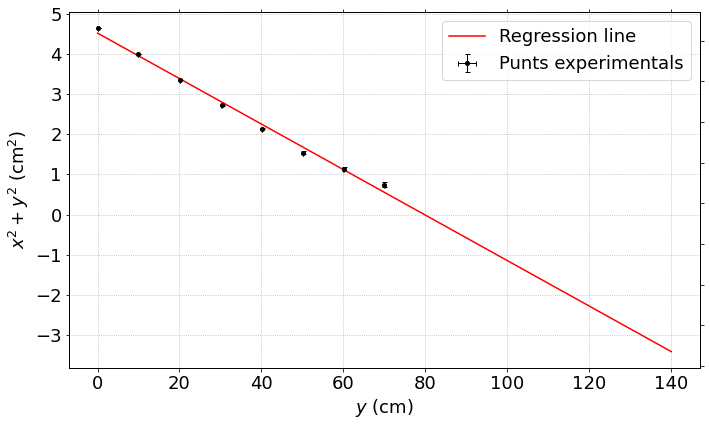

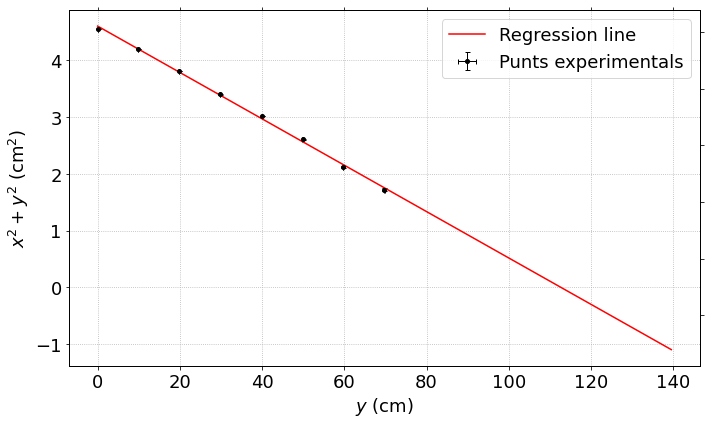

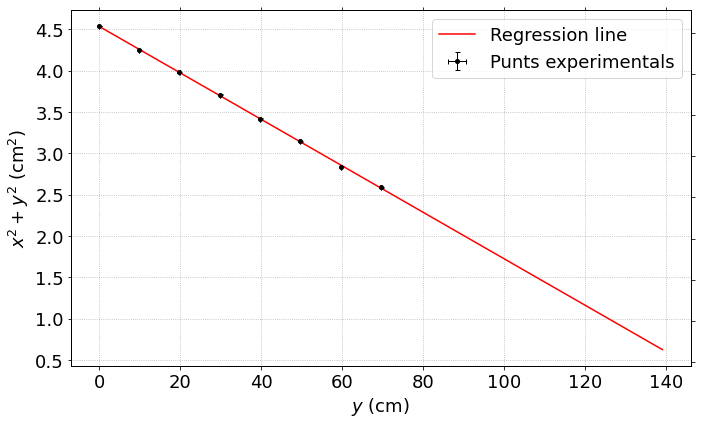

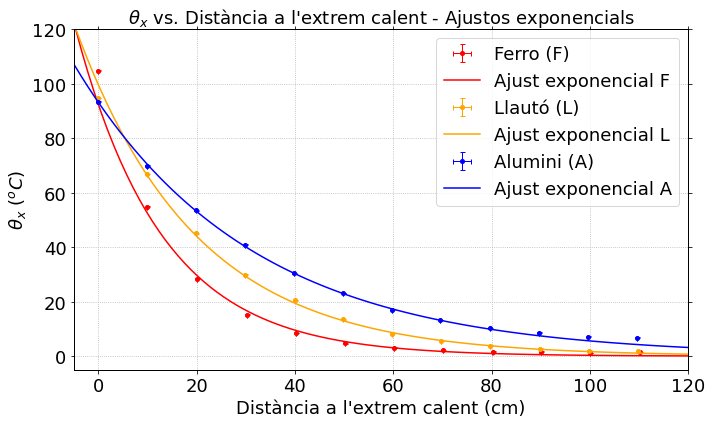

In [4]:
# Mesures inicials:
diametre_ferro = Measure("Diametre ferro", "d_ferro", [3.010,0.005],"cm")
diametre_llauto = Measure("Diametre llauto", "d_llauto", [3.005,0.005],"cm")
diametre_alumini = Measure("Diametre alumini", "d_alumini", [3.005,0.005],"cm")

T_ambient = Measure("Temperatura ambient", "T_a", [25.4,0.1], "C")

d_A = [9.820, 10.000, 9.980, 9.965, 9.915, 9.965, 9.895, 10.205, 9.960, 9.910, 9.9615]

d_L = [9.895, 9.950, 9.925, 10.145, 9.900, 9.920, 10.000, 9.920, 10.080, 9.985, 9.972]

d_F = [9.830, 10.310, 10.125, 9.965, 9.895, 9.935, 9.995, 10.120, 9.895, 9.880, 10.150]


# --- NEW: distances per bar as Vector_Measure (units cm; set your real inc) ---
avg_F = Measure_list("Separació Ferro",   "s_F", d_F, 0.005,"cm")
avg_L = Measure_list("Separació Llautó",  "s_L", d_L, 0.005,"cm")
avg_A = Measure_list("Separació Alumini", "s_A", d_A, 0.005,"cm")

print(avg_F)
print(avg_L)
print(avg_A)

# --- NEW: distances per bar as Vector_Measure (units cm; set your real inc) ---
s_F_v = Vector_Measure("Separació Ferro",   "s_F", [d_F, [0.005]*len(d_F)], "cm")
s_L_v = Vector_Measure("Separació Llautó",  "s_L", [d_L, [0.005]*len(d_L)], "cm")
s_A_v = Vector_Measure("Separació Alumini", "s_A", [d_A, [0.005]*len(d_A)], "cm")

# --- Sum segments (Vector_Measure -> one total Measure) using ONLY formulador ---
def longitud_from_segments(vm_vector, name, varname, unit="cm"):
    zero = Measure(name + " zero", varname + "_z", [0.0, 0.0], unit)
    total = zero
    for i, seg in enumerate(vm_vector.measure_vector, start=1):
        total = formulador(total.var + seg.var, [total, seg],
                           f"{name} parcial {i}", f"{varname}_p{i}", unit)
    # Re-label the final total as the requested name/var
    return formulador(total.var, [total], name, varname, unit)

# Build longitud (total length) for each bar
Long_F = longitud_from_segments(s_F_v, "Longitud Ferro",   "L_F", "cm")
Long_L = longitud_from_segments(s_L_v, "Longitud Llautó",  "L_L", "cm")
Long_A = longitud_from_segments(s_A_v, "Longitud Alumini", "L_A", "cm")

# (optional) quick check
crear_taula([Long_F, Long_L, Long_A])

# --- Build cumulative-distance Vector_Measures from your segment Vector_Measures (propagates σ) ---
def cumulative_from_segments(vm_vector, name_prefix, var_prefix, unit="cm"):
    # start at 0 ± 0 (same unit)
    zero = Measure(f"{name_prefix} 0", f"{var_prefix}_0", [0.0, 0.0], unit)
    running = zero
    cum_measures = [zero]
    for i, seg in enumerate(vm_vector.measure_vector, start=1):
        # running_{i} = running_{i-1} + seg  (uncertainty via formulador on .var)
        running = formulador(running.var + seg.var, [running, seg],
                             f"{name_prefix} acumulada {i}",
                             f"{var_prefix}_{i}", unit)
        cum_measures.append(running)
    # pack back into a Vector_Measure
    mags = [m.magnitude for m in cum_measures]
    incs = [m.incertesa for m in cum_measures]
    return Vector_Measure(f"{name_prefix} acumulada", f"{var_prefix}_cum", [mags, incs], unit), cum_measures

# Build cumulative vectors for each bar
s_F_cum_v, s_F_cum_list = cumulative_from_segments(s_F_v, "Separació Ferro",   "sF", "cm")
s_L_cum_v, s_L_cum_list = cumulative_from_segments(s_L_v, "Separació Llautó", "sL", "cm")
s_A_cum_v, s_A_cum_list = cumulative_from_segments(s_A_v, "Separació Alumini","sA", "cm")

# --- Use these cumulative distances in your existing workflow ---
dist_tubes = [s_F_cum_v.measure_vector, s_L_cum_v.measure_vector, s_A_cum_v.measure_vector]

tf_list = [26.8, 26.6, 27.0, 27.0, 27.5, 28.5, 30.1, 33.9, 40.6, 53.9, 80.3, 130.2]

tl_list = [27.3, 27.4, 28.1, 29.2, 31.0, 33.7, 39.0, 45.9, 55.3, 70.5, 92.3, 120.2]

ta_list = [32.2, 32.6, 34.0, 35.7, 38.7, 42.5, 48.6, 55.9, 66.3, 78.9, 95.3, 118.9]
tf_list = list(reversed(tf_list))
tl_list = list(reversed(tl_list))
ta_list = list(reversed(ta_list))
inc_list = [0.1]* 12
T_F = Vector_Measure("Temperatura ferro", "T_Ferro", [tf_list, inc_list], "C")
T_L = Vector_Measure("Temperatura llauto", "T_Llauto", [tl_list,inc_list], "C")
T_A = Vector_Measure("Temperatura alumini", "T_Alumini", [ta_list, inc_list], "C")

# T_ambient_vector = Vector_Measure("Temperatura ambient vector", "T_a_v", [[T_ambient.magnitude]* len(T_F.measure_vector), [T_ambient.incertesa] * len(T_F.measure_vector) ], "C")
theta_F, theta_L, theta_A = [],[],[]
theta_tubes = [theta_F, theta_L, theta_A]
tube = 0
for tube_measures in  [T_F, T_L, T_A]:
    for temp_measure in tube_measures.measure_vector:
        theta_tubes[tube].append(diff([temp_measure, T_ambient]))
    tube += 1
    

mydata = []
MAX_SEPARATION = 120.001
var("PARAM_a PARAM_b")
domain = np.linspace(-10, MAX_SEPARATION, 100)

def fer_log(mes):
    return formulador(log(mes.var), [mes], mes.name + "_log", mes.var_name + "_lg", "logC")

pre_data, pre_reg = [], []



# --- before the loop, add: ---
fit_params = []
tube_names = ["Ferro (F)", "Llautó (L)", "Alumini (A)"]
tube_codes = ["F", "L", "A"]

other_list=[]

# --- inside your existing loop over tubes, just use these distances ---
for tube_idx, tube_data in enumerate(theta_tubes):
    dists = dist_tubes[tube_idx]  # list of Measure distances for this bar
    print(dists)
    mydata.append([(s, theta) for theta, s in zip(tube_data, dists)])

    data_magnitudes = [(s.magnitude, theta.magnitude) for theta, s in zip(tube_data, dists)]

    reg_data = [(s, fer_log(theta)) for theta, s in zip(tube_data[:-4], dists[:-4])]
    other = [(s, fer_log(theta)) for theta, s in zip(tube_data[-4:], dists[-4:])]
    
    
    
    reg_a, reg_b, reg_r, _, _ = regresio(reg_data, r"$y$", r"cm", r"$x^{2} + y ^{2}$", r"cm$^2$", r"", "display",
                                         fouraxis=True, grid=True, percentdreta=1, percentesquerra=-1)
    reg_data.extend(other)
    pre_data.append(reg_data)
    pre_reg.append((reg_a, reg_b, reg_r))

    # Model is ln(theta) = reg_a + reg_b * s  ⇒  theta(s) = exp(reg_a) * e^(reg_b s)
    a = formulador(e**(reg_a.var), [reg_a], f"Theta_0_reg_{tube_codes[tube_idx]}", f"theta0_{tube_codes[tube_idx]}", "T")
    b = reg_b
    # For f(x) = a * e^(-p x), set p = -b
    p = formulador(-b.var, [b], f"p_{tube_codes[tube_idx]}", f"p_{tube_codes[tube_idx]}", r"cm^{-1}")
    fit_params.append((tube_names[tube_idx], a, p))

    model(x) = PARAM_a*e**(PARAM_b*x)
    fitted_model = model(PARAM_a=a.magnitude, PARAM_b=b.magnitude)
    mydata.append([(s_x, fitted_model(s_x)) for s_x in domain])
    
# --- after the loop, print the a and p values for each bar ---
for name, a_meas, p_meas in fit_params:
    print(f"{name}: a = {a_meas} ,  p = {p_meas}  (f(x) = a * e^(-p x))")

# --- in your final graph_display call, only change legend texts for Ferro and add ymin ---
graph_display(
    mydata,
    r"Distància a l'extrem calent",  "cm",
    r"$\theta_x$", r"$^o C$",
    r"$\theta_x$ vs. Distància a l'extrem calent - Ajustos exponencials", "parte1exponenciales",
    labels=[
        "Ferro (F)", "Ajust exponencial F",       # CHANGED (was "Ferro", "Ajust exponencial pel Ferro")
        "Llautó (L)",    "Ajust exponencial L",
        "Alumini (A)",   "Ajust exponencial A"
    ],
    xmin = -5.0001, xmax = MAX_SEPARATION, ymin = -5.0001, ymax = 120.00001,  # CHANGED: ymin added
    llista_teos = ["o",":"] * 3,
    colors = ["red","red","orange","orange","blue","blue"],
    grid = True, fouraxis=True
)

[('A: (4.527046898353793 +/- 0.07969009628086281) cm$^2$', 'B: (-0.05673800047333791 +/- 0.0019006119990448657)  units ', 'Coe: (0.9933123128344941 +/- 0.100000000000000)  '), ('A: (4.602207966361314 +/- 0.02666467675102905) cm$^2$', 'B: (-0.04085406995141924 +/- 0.0006400655983349673)  units ', 'Coe: (0.998529413996846 +/- 0.100000000000000)  '), ('A: (4.535416893954604 +/- 0.007470628092214162) cm$^2$', 'B: (-0.02811800945132433 +/- 0.00017974138664344927)  units ', 'Coe: (0.9997548839128676 +/- 0.100000000000000)  ')]


(<Figure size 720x432 with 3 Axes>,
 <AxesSubplot:xlabel="Distància a l'extrem calent (cm)", ylabel='$log(\\theta_x / ^0 C)$ (sense unitats)'>)

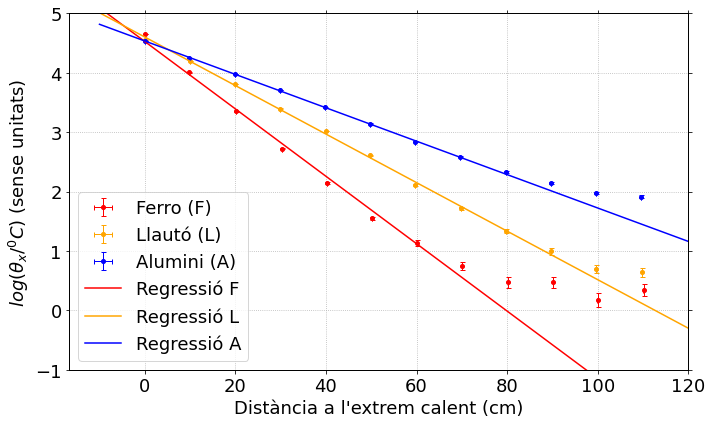

In [5]:
regresions = []
print(pre_reg)
for pack in pre_reg:
    domain = np.linspace(-10,125, 1000)
    regresions.append([(x,pack[0].magnitude +  pack[1].magnitude*x) for x in domain])

pre_data_copy = pre_data.copy()
pre_data_copy.extend(regresions)
graph_display(pre_data_copy,r"Distància a l'extrem calent", r"cm", r"$log(\theta_x / ^0 C)$",
            "sense unitats","","titol", labels = ["Ferro (F)", "Llautó (L)","Alumini (A)","Regressió F","Regressió L","Regressió A"],
            ymin = -1, ymax = 5, xmax= 120.0001,
             llista_teos = ["o","o","o","--","--","--"], colors = ["red","orange","blue"] *2, grid = True, fouraxis=True)



[('A: (4.527046898353793 +/- 0.07969009628086281) cm$^2$', 'B: (-0.05673800047333791 +/- 0.0019006119990448657)  units ', 'Coe: (0.9933123128344941 +/- 0.100000000000000)  '), ('A: (4.602207966361314 +/- 0.02666467675102905) cm$^2$', 'B: (-0.04085406995141924 +/- 0.0006400655983349673)  units ', 'Coe: (0.998529413996846 +/- 0.100000000000000)  '), ('A: (4.535416893954604 +/- 0.007470628092214162) cm$^2$', 'B: (-0.02811800945132433 +/- 0.00017974138664344927)  units ', 'Coe: (0.9997548839128676 +/- 0.100000000000000)  ')]


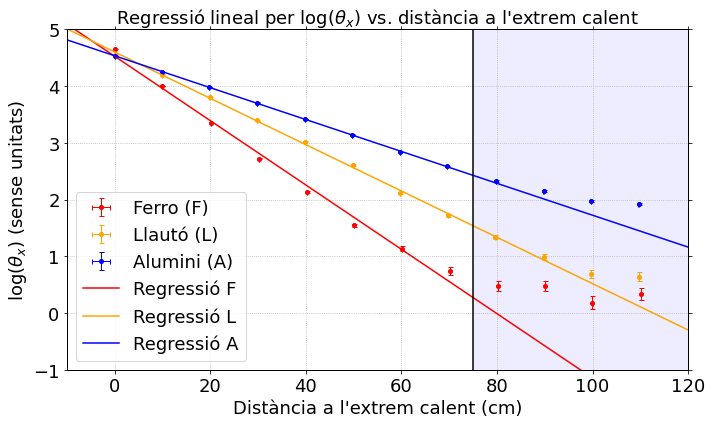

In [6]:
regresions = []
print(pre_reg)
for pack in pre_reg:
    domain = np.linspace(-10, 125, 1000)
    regresions.append([(x, pack[0].magnitude + pack[1].magnitude * x) for x in domain])

pre_data_copy = pre_data.copy()
pre_data_copy.extend(regresions)

# --- NEW: vertical line at x = 75 cm as a dataset built with np.linspace over the Y-range you use ---
vline_y = np.linspace(-1, 5, 400)  # same ymin/ymax you pass to graph_display
vline75 = [(75.0, y) for y in vline_y]
pre_data_copy.append(vline75)

# Extend legend/style arrays by one entry for the vertical line
fig, ax = graph_display(
    pre_data_copy,
    r"Distància a l'extrem calent", r"cm",
    r"$\log(\theta_x)$", "sense unitats",
    r"Regressió lineal per $\log(\theta_x)$ vs. distància a l'extrem calent", "titol",
    labels=["Ferro (F)", "Llautó (L)", "Alumini (A)", "Regressió F", "Regressió L", "Regressió A", ""],
    ymin=-1, ymax=5, xmax=120.0001, xmin=-10,
    llista_teos=["o", "o", "o", "--", "--", "--", "--"],
    colors=(["red", "orange", "blue"] * 2) + ["black"],
    grid=True, fouraxis=True
)

# --- NEW: shade the region to the right of 75 cm ---
ax.axvspan(75.0, ax.get_xlim()[1], facecolor="blue", alpha=0.07, zorder=0)


In [7]:
# Function (unchanged math): returns k_i/k_j from p_i, p_j
def k_ratio_from_p(p_i, p_j, name, var):
    expr = (p_j.var / p_i.var)**2
    return formulador(expr, [p_i, p_j], name, var, "")  # unitless

# Corrected calls (note the order!):
p_F = fit_params[0][2]
p_L = fit_params[1][2]
p_A = fit_params[2][2]

k_L_over_F = k_ratio_from_p(p_L, p_F, "k_L / k_F", "kL_kF")
k_A_over_F = k_ratio_from_p(p_A, p_F, "k_A / k_F", "kA_kF")
k_A_over_L = k_ratio_from_p(p_A, p_L, "k_A / k_L", "kA_kL")

# quick view
crear_taula([k_L_over_F, k_A_over_F, k_A_over_L])

print("Eq.(5) conductivity ratios from p:")
print("  k_L/k_F =", k_L_over_F)
print("  k_A/k_F =", k_A_over_F)
print("  k_A/k_L =", k_A_over_L)

/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:165: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)
See http://trac.sagemath.org/5930 for details.
/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:166: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)
See http://trac.sagemath.org/5930 for details.


Name,Magnitude,Incertesa,Units,Incertesa Instrumental (if available)
k_A / k_F,4.07172940168671,0.277712435040642,,N/A
k_A / k_L,2.11106454158308,0.0714427823940542,,N/A
k_L / k_F,1.92875647403624,0.142653809182987,,N/A


Eq.(5) conductivity ratios from p:
  k_L/k_F = 'K_l / k_f: (1.92875647403624 +/- 0.142653809182987) '
  k_A/k_F = 'K_a / k_f: (4.07172940168671 +/- 0.277712435040642) '
  k_A/k_L = 'K_a / k_l: (2.11106454158308 +/- 0.0714427823940542) '


In [8]:
# Reference conductivity (no uncertainty)
k_F = Measure("Conductivitat Ferro (ref)", "k_F", [80.0, 0.0], "W m^{-1} K^{-1}")

# k_L = (k_L/k_F) * k_F
k_L = formulador(k_L_over_F.var * k_F.var, [k_L_over_F, k_F],
                 "Conductivitat Llautó", "k_L", "W m^{-1} K^{-1}")

# k_A via F: k_A = (k_A/k_F) * k_F
k_A_vF = formulador(k_A_over_F.var * k_F.var, [k_A_over_F, k_F],
                    "Conductivitat Alumini (via F)", "k_A_vF", "W m^{-1} K^{-1}")

# k_A via L: k_A = (k_A/k_L) * k_L
k_A_vL = formulador(k_A_over_L.var * k_L.var, [k_A_over_L, k_L],
                    "Conductivitat Alumini (via L)", "k_A_vL", "W m^{-1} K^{-1}")

# Quick view
crear_taula([k_F, k_L, k_A_vF, k_A_vL])

print("k_F =", k_F)
print("k_L =", k_L)
print("k_A (via F) =", k_A_vF)
print("k_A (via L) =", k_A_vL)

/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:165: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)
See http://trac.sagemath.org/5930 for details.
/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:166: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)
See http://trac.sagemath.org/5930 for details.


Name,Magnitude,Incertesa,Units,Incertesa Instrumental (if available)
Conductivitat Alumini (via F),325.738352134937,22.2169948032514,W m^{-1} K^{-1},N/A
Conductivitat Alumini (via L),325.738352134937,26.4943559441075,W m^{-1} K^{-1},N/A
Conductivitat Ferro (ref),80,0,W m^{-1} K^{-1},N/A
Conductivitat Llautó,154.300517922899,11.412304734639,W m^{-1} K^{-1},N/A


k_F = 'Conductivitat ferro (ref): (80.0000000000000 +/- 0.000000000000000) W m^{-1} K^{-1}'
k_L = 'Conductivitat llautó: (154.300517922899 +/- 11.4123047346390) W m^{-1} K^{-1}'
k_A (via F) = 'Conductivitat alumini (via f): (325.738352134937 +/- 22.2169948032514) W m^{-1} K^{-1}'
k_A (via L) = 'Conductivitat alumini (via l): (325.738352134937 +/- 26.4943559441075) W m^{-1} K^{-1}'


## PART 1a (Permanent):


In [9]:
diametre_P = Measure("Diametre ferro", "d_ferro", [5.1,0.1],"cm")
diametre_R= Measure("Diametre llauto", "d_llauto", [3.0,0.1],"cm")


In [10]:
# ——— READ /mnt/data/dimecres1 INTO COLUMN LISTS (no pandas) ———
import re

def read_periodic_columns(path, has_header=True, encoding="utf-8"):
    """
    Reads a whitespace/tab separated text file for the periodic regime.
    - Header cells may contain spaces (e.g., 't.gran 0cm'); we split header on 2+ spaces or tabs.
    - Data lines are split on any whitespace.
    Returns a dict: {normalized_header: list_of_floats_or_strings}.
    Normalization: non-alphanumerics -> '_', strip leading/trailing '_', lowercase.
    """
    with open(path, "r", encoding=encoding) as f:
        lines = [ln.strip() for ln in f if ln.strip()]

    if not lines:
        return {}

    header_cols = None
    data_lines = lines

    if has_header:
        header_line = lines[0]
        # Keep header tokens like "t.gran 0cm" together; split on 2+ spaces or tabs
        header_cols = re.split(r"\s{2,}|\t+", header_line.strip())
        data_lines = lines[1:]

    # Parse data rows on any whitespace
    rows = []
    for ln in data_lines:
        parts = re.split(r"\s+", ln.strip())
        if parts:
            rows.append(parts)

    if not rows:
        if header_cols:
            names = [re.sub(r"[^0-9A-Za-z]+", "_", h).strip("_").lower() for h in header_cols]
            return {name: [] for name in names}
        return {}

    ncols = max(len(r) for r in rows)
    cols = [[] for _ in range(ncols)]
    for r in rows:
        for j in range(ncols):
            val = r[j] if j < len(r) else ""
            # Try float, otherwise keep raw string
            try:
                cols[j].append(float(val))
            except Exception:
                cols[j].append(val)

    if header_cols and len(header_cols) == ncols:
        names = [re.sub(r"[^0-9A-Za-z]+", "_", h).strip("_").lower() for h in header_cols]
    else:
        names = [f"col{j+1}" for j in range(ncols)]

    return dict(zip(names, cols))


# —— LOAD YOUR FILE ——
PATH = "dimecres1"  # your uploaded file
data = read_periodic_columns(PATH, has_header=True)

# Inspect available keys (normalized)
print("Columns found:", sorted(data.keys()))

# If the header matches your preview, you’ll get:
# 'temps_s', 't_gran_0cm', 't_gran_10cm', 't_gran_15cm', 't_petita_0cm', 't_petita_10cm', 't_petita_20cm'
# Bind them to short variables (if present):
t          = data.get('temps_s', [])
t_gran_0   = data.get('t_gran_0cm', [])
t_gran_10  = data.get('t_gran_10cm', [])
t_gran_15  = data.get('t_gran_15cm', [])
t_petita_0 = data.get('t_petita_0cm', [])
t_petita_10= data.get('t_petita_10cm', [])
t_petita_20= data.get('t_petita_20cm', [])

# Quick peek
for name in ['temps_s','t_gran_0cm','t_gran_10cm','t_gran_15cm','t_petita_0cm','t_petita_10cm','t_petita_20cm']:
    if name in data:
        arr = data[name]
        print(f"{name}: n={len(arr)}  head={arr[:3]}")


Columns found: ['t_gran_0cm', 't_gran_10cm', 't_gran_15cm', 't_petita_0cm', 't_petita_10cm', 't_petita_20cm', 'temps_s']
temps_s: n=854  head=[9.288, 17.717, 26.144]
t_gran_0cm: n=854  head=[83.434464, 83.567009, 83.807632]
t_gran_10cm: n=854  head=[72.968346, 72.992645, 73.059853]
t_gran_15cm: n=854  head=[69.153023, 69.129875, 69.165939]
t_petita_0cm: n=854  head=[99.21981, 99.596924, 99.958672]
t_petita_10cm: n=854  head=[80.23484, 80.324837, 80.383217]
t_petita_20cm: n=854  head=[67.419426, 67.362709, 67.328247]


In [11]:
print(t_gran_0[97])
print(t_gran_0[96])
print(t_gran_0[95])

86.28772
86.302437
86.260628


In [12]:
# ——— Convert numeric columns to Measures with fixed uncertainties and plot with graph_display ———
import numpy as np
from uuid import uuid4

# Helpers for unique names/varnames
def _uniq(s=""):
    return (s + "_" if s else "") + str(uuid4())[:8]

# Fixed uncertainties
SIGMA_T   = 8.5   # s  for time
SIGMA_TEMP= 0.2      # °C for temperatures

# 1) Extract and time-sort numeric columns
t = data['temps_s']
g0 = data['t_gran_0cm']; g10 = data['t_gran_10cm']; g15 = data['t_gran_15cm']
p0 = data['t_petita_0cm']; p10 = data['t_petita_10cm']; p20 = data['t_petita_20cm']

order = sorted(range(len(t)), key=lambda i: t[i])
t_sorted  = [t[i] for i in order]
g0, g10, g15 = [ [series[i] for i in order] for series in (g0, g10, g15) ]
p0, p10, p20 = [ [series[i] for i in order] for series in (p0, p10, p20) ]

# 2) Wrap into Measure objects
time_measures = [ Measure(f"Temps {i}", f"t_{i}", [float(tt), SIGMA_T], "s") for i, tt in enumerate(t_sorted) ]

def wrap_temp_series(vals, tag):
    return [ Measure(f"T {tag} {i}", f"T_{tag}_{i}", [float(v), SIGMA_TEMP], "C") for i, v in enumerate(vals) ]

g0_M, g10_M, g15_M = wrap_temp_series(g0,"g0"), wrap_temp_series(g10,"g10"), wrap_temp_series(g15,"g15")
p0_M, p10_M, p20_M = wrap_temp_series(p0,"p0"), wrap_temp_series(p10,"p10"), wrap_temp_series(p20,"p20")

# 3) Build tuples of measures (x,y)
def make_series_measures(x_meas_list, y_meas_list):
    return list(zip(x_meas_list, y_meas_list))


# Averages
avg_g0, avg_g10, avg_g15 = np.mean(g0), np.mean(g10), np.mean(g15)
avg_p0, avg_p10, avg_p20 = np.mean(p0), np.mean(p10), np.mean(p20)

# 5) Horizontal average lines as tuples of measures (reuse the same avg Measure along time)
def hline_avg(x_meas_list, avg_measure_obj):
    return [(xm, avg_measure_obj) for xm in x_meas_list]

# Datasets (each: data series, then its mean line)
dataset_gran = [
    make_series_measures(time_measures, g0_M),  hline_avg(time_measures, avg_g0),
    make_series_measures(time_measures, g10_M), hline_avg(time_measures, avg_g10),
    make_series_measures(time_measures, g15_M), hline_avg(time_measures, avg_g15),
]
dataset_petita = [
    make_series_measures(time_measures, p0_M),  hline_avg(time_measures, avg_p0),
    make_series_measures(time_measures, p10_M), hline_avg(time_measures, avg_p10),
    make_series_measures(time_measures, p20_M), hline_avg(time_measures, avg_p20),
]

# 6) Axis limits from magnitudes
xmin, xmax = min(m.magnitude for m in time_measures), max(m.magnitude for m in time_measures)
all_g_mag = [m.magnitude for m in (g0_M + g10_M + g15_M)]
all_p_mag = [m.magnitude for m in (p0_M + p10_M + p20_M)]
ymin_g, ymax_g = min(all_g_mag), max(all_g_mag)
ymin_p, ymax_p = min(all_p_mag), max(all_p_mag)

# 7) Styles/colors
styles = ["o", "--"] * 3
colors_g = ["red","red","orange","orange","blue","blue"]
colors_p = ["purple","purple","green","green","brown","brown"]

print(f"<T> gran 0cm = {avg_g0:.3f}  |  <T> gran 10cm = {avg_g10:.3f}  |  <T> gran 15cm = {avg_g15:.3f}")
print(f"<T> petita 0cm = {avg_p0:.3f}  |  <T> petita 10cm = {avg_p10:.3f}  |  <T> petita 20cm = {avg_p20:.3f}")


<T> gran 0cm = 83.871  |  <T> gran 10cm = 74.188  |  <T> gran 15cm = 70.177
<T> petita 0cm = 100.463  |  <T> petita 10cm = 82.407  |  <T> petita 20cm = 68.716


(<Figure size 720x432 with 3 Axes>,
 <AxesSubplot:title={'center':'Règim permanent $T$ vs. $x$ a (0, 10, 20 cm) barra petita'}, xlabel='Temps (s)', ylabel='Temperatura ($^\\circ$C)'>)

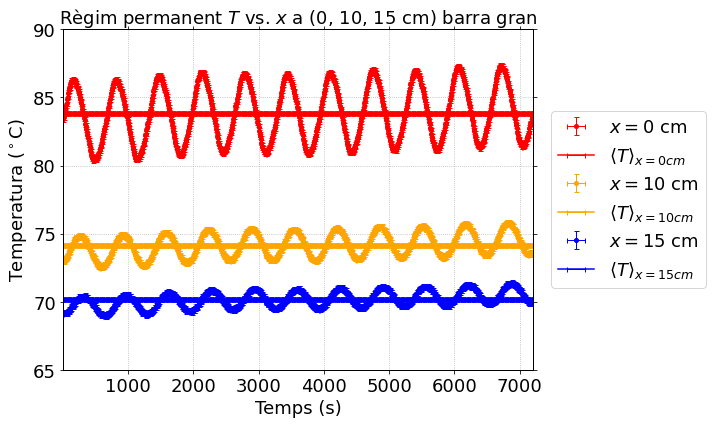

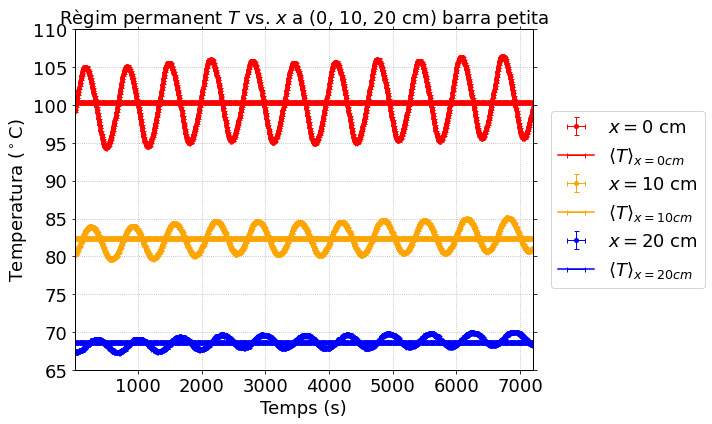

In [13]:
graph_display(
    dataset_gran,
    r"Temps", "s",
    r"Temperatura", r"$^\circ$C",
    r"Règim permanent $T$ vs. $x$ a (0, 10, 15 cm) barra gran",
    r"Règim periòdic — barra gran (0, 10, 15 cm)",
    labels=[
        r"$x= 0$ cm", r"$\langle T \rangle _{x=0cm}$",
        r"$x= 10$ cm", r"$\langle T \rangle _{x=10cm}$",
        r"$x= 15$ cm", r"$\langle T \rangle _{x=15cm}$",
    ],
    xmin=xmin, xmax=xmax,
    ymin=65, ymax=90,
    llista_teos=styles,
    colors=colors_g,
    grid=True,
    fouraxis=True,
    legend_outside=True
)

graph_display(
    dataset_petita,
    r"Temps", "s",
    r"Temperatura", r"$^\circ$C",
    r"Règim permanent $T$ vs. $x$ a (0, 10, 20 cm) barra petita",
    r"Règim periòdic — barra petita (0, 10, 20 cm)",
    labels=[
        r"$x= 0$ cm", r"$\langle T \rangle _{x=0cm}$",
        r"$x= 10$ cm", r"$\langle T \rangle _{x=10cm}$",
        r"$x= 20$ cm", r"$\langle T \rangle _{x=20cm}$",
    ],
    xmin=xmin, xmax=xmax,
    ymin=65, ymax=110,
    llista_teos=styles,
    colors=colors_g,
    grid=True,
    fouraxis=True,
    legend_outside=True
)


In [14]:
def subtract_ambient_series(series_M, T_ambient, tag=""):
    return [formulador(series_M[i].var - T_ambient.var, [series_M[i], T_ambient],
                        f"{series_M[i].name}-T_ambient",
                        f"{series_M[i].var_name}_mTa_{_uniq()}",
                        "C")
            for i in range(len(series_M))]

# Apply to all g and p lists
g0_centered  = subtract_ambient_series(g0_M,  T_ambient, "g0")
g10_centered = subtract_ambient_series(g10_M, T_ambient, "g10")
g15_centered = subtract_ambient_series(g15_M, T_ambient, "g15")
p0_centered  = subtract_ambient_series(p0_M,  T_ambient, "p0")
p10_centered = subtract_ambient_series(p10_M, T_ambient, "p10")
p20_centered = subtract_ambient_series(p20_M, T_ambient, "p20")

/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:165: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)
See http://trac.sagemath.org/5930 for details.
/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:166: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)
See http://trac.sagemath.org/5930 for details.


In [15]:
# ——————————————————— PERIODIC REGIME: GUIDE 1b IMPLEMENTATION ———————————————————
import numpy as np
import math
from uuid import uuid4
var("PARAM_a PARAM_b")

# ——— helpers for unique names/varnames ———
def _uniq(s=""):
    return (s + "_" if s else "") + str(uuid4())[:8]

# ——— small algebra helpers (always return via formulador with .var) ———
def mean_measure(lst, name, vname, unit):
    expr = sum(m.var for m in lst)/len(lst)
    return formulador(expr, lst, f"{name}_{_uniq('mean')}", f"{vname}_{_uniq('mean')}", unit)

def diff_m(m2, m1, name, vname, unit):
    print(m2,m1)
    expr = m2.var - m1.var
    return formulador(expr, [m2, m1], f"{name}_{_uniq('diff')}", f"{vname}_{_uniq('diff')}", unit)

def ratio_m(m2, m1, name, vname, unit):
    expr = m2.var / m1.var
    return formulador(expr, [m2, m1], f"{name}_{_uniq('ratio')}", f"{vname}_{_uniq('ratio')}", unit)

def scalar_mul(s, m, name, vname, unit):
    expr = s * m.var
    return formulador(expr, [m], f"{name}_{_uniq('sm')}", f"{vname}_{_uniq('sm')}", unit)

def log_m(m, name, vname, unit=""):
    expr = log(m.var)
    return formulador(expr, [m], f"{name}_{_uniq('log')}", f"{vname}_{_uniq('log')}", unit)

def sqrt_m(m, name, vname, unit):
    expr = sqrt(m.var)
    return formulador(expr, [m], f"{name}_{_uniq('sqrt')}", f"{vname}_{_uniq('sqrt')}", unit)

def mean_or_measure_list(vals, name, varname, unit):
    """If all Measures in vals share the same uncertainty, return a Measure_list; else mean_measure."""
    if not vals:
        return None
    try:
        incs = [v.incertesa for v in vals]
        mags = [v.magnitude for v in vals]
    except Exception:
        # Fallback to mean if something isn't a Measure
        return mean_measure(vals, name, varname, unit)
    same = all(incs[0] == x for x in incs)
    if same:
        print(f"[INFO] {name}: all {len(vals)} values have the same uncertainty = {incs[0]}. Using Measure_list.")
        return Measure_list(name, varname, mags, incs[0], unit)
    else:
        return mean_measure(vals, name, varname, unit)
    
    
# ——— 0) constants / geometry (meters; conductivities SI) ———
  # W/(m·K)  (from guide initial values)
# ——— GEOMETRY UPDATE: diameters as MEASURES (σ = 0.1 cm) + radius in meters via formulador ———
from uuid import uuid4
def _uniq(s=""):
    return (s + "_" if s else "") + str(uuid4())[:8]

# 1) Measured diameters (edit the nominal values if needed; σ = 0.1 cm)
d_gran_cm   = Measure("Diàmetre barra gran",   "d_gran_cm",   [5.10, 0.10], "cm")
d_petita_cm = Measure("Diàmetre barra petita", "d_petita_cm", [3.00, 0.10], "cm")

# 2) Radii in cm: r = d/2
def radius_from_diam_cm(d_cm):
    expr = d_cm.var / 2.0
    return formulador(expr, [d_cm],
                      f"Radi {d_cm.name} (cm)",
                      f"r_{d_cm.var_name}_cm_{_uniq('r')}",
                      "cm")

r_gran_cm   = radius_from_diam_cm(d_gran_cm)
r_petita_cm = radius_from_diam_cm(d_petita_cm)

# 3) Convert to meters: r_m = r_cm / 100
def cm_to_m(meas_cm, newname=None, newvar=None):
    expr = meas_cm.var / 100.0
    return formulador(expr, [meas_cm],
                      newname or (meas_cm.name.replace("(cm)", "").strip() + " (m)"),
                      newvar  or (meas_cm.var_name.replace("_cm","") + "_m_" + _uniq("m")),
                      "m")

r_gran_m   = cm_to_m(r_gran_cm,   "Radi barra gran (m)",   "r_gran_m")
r_petita_m = cm_to_m(r_petita_cm, "Radi barra petita (m)", "r_petita_m")

# posicions (as Measures, in cm; convert to m when needed)
xg0 = Measure("Distància gran 0cm",  "xg0", [0.0, 0.05], "cm")
xg10= Measure("Distància gran 10cm", "xg10",[10.0,0.05], "cm")
xg15= Measure("Distància gran 15cm", "xg15",[15.0,0.05], "cm")

xp0 = Measure("Distància petita 0cm", "xp0", [0.0, 0.05], "cm")
xp10= Measure("Distància petita 10cm","xp10",[10.0,0.05], "cm")
xp20= Measure("Distància petita 20cm","xp20",[20.0,0.05], "cm")

def cm_to_m(M):
    expr = (M.var) / 100.0
    return formulador(expr, [M], f"{M.name} (m)", f"{M.var_name}_m", "m")

xg0_m, xg10_m, xg15_m = map(cm_to_m, (xg0, xg10, xg15))
xp0_m, xp10_m, xp20_m = map(cm_to_m, (xp0, xp10, xp20))

# ——— 1) Averages per trace and ambient removal (Φ0) ———
# If you already have T_ambient as a Measure, we will use it. Else estimate from early 10% of 0cm channels.
T_ambient = Measure("Temperatura ambient", "T_a", [25.4,0.1], "C")

# Average temperatures:
mu_g0  = mean_or_measure_list(g0_M,  "Mitjana T gran 0cm",   "mu_g0",  "C")
mu_g10 = mean_or_measure_list(g10_M, "Mitjana T gran 10cm",  "mu_g10", "C")
mu_g15 = mean_or_measure_list(g15_M, "Mitjana T gran 15cm",  "mu_g15", "C")
mu_p0  = mean_or_measure_list(p0_M,  "Mitjana T petita 0cm", "mu_p0",  "C")
mu_p10 = mean_or_measure_list(p10_M, "Mitjana T petita 10cm","mu_p10", "C")
mu_p20 = mean_or_measure_list(p20_M, "Mitjana T petita 20cm","mu_p20", "C")

# Define Φ for every μ: Φ_pos = μ_pos − T_ambient  (all as Measures via formulador)

def phi_from_mu(mu_M, label):
    return diff_m(mu_M, T_ambient, f"Phi {label}", f"Phi_{label}", "C")

# Barra gran
Phi_g0   = phi_from_mu(mu_g0,  "gran_0cm")
Phi_g10  = phi_from_mu(mu_g10, "gran_10cm")
Phi_g15  = phi_from_mu(mu_g15, "gran_15cm")

# Barra petita
Phi_p0   = phi_from_mu(mu_p0,  "petita_0cm")
Phi_p10  = phi_from_mu(mu_p10, "petita_10cm")
Phi_p20  = phi_from_mu(mu_p20, "petita_20cm")


print(mu_g0)
print(mu_g10)
print(mu_g15)
print(mu_p0)
print(mu_p10)
print(mu_p20)

[INFO] Mitjana T gran 0cm: all 854 values have the same uncertainty = 0.200000000000000. Using Measure_list.
[INFO] Mitjana T gran 10cm: all 854 values have the same uncertainty = 0.200000000000000. Using Measure_list.
[INFO] Mitjana T gran 15cm: all 854 values have the same uncertainty = 0.200000000000000. Using Measure_list.
[INFO] Mitjana T petita 0cm: all 854 values have the same uncertainty = 0.200000000000000. Using Measure_list.
[INFO] Mitjana T petita 10cm: all 854 values have the same uncertainty = 0.200000000000000. Using Measure_list.
[INFO] Mitjana T petita 20cm: all 854 values have the same uncertainty = 0.200000000000000. Using Measure_list.
Mitjana t gran 0cm: (83.87064268852463 +/- 0.211797225716620) C
	[Stdev : 2.036857225569205, Inc. Instrumental:0.200000000000000] 'Temperatura ambient: (25.4000000000000 +/- 0.100000000000000) C'
Mitjana t gran 10cm: (74.18813320023412 +/- 0.202150550874087) C
	[Stdev : 0.8594055019413099, Inc. Instrumental:0.200000000000000] 'Tempera

/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:165: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)
See http://trac.sagemath.org/5930 for details.
/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:166: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)
See http://trac.sagemath.org/5930 for details.


In [16]:
# ——— Fit T(t) = C + D t + R cos(ω t − φ) and extract all maxima as Measures ———
import numpy as np
from numpy.fft import rfftfreq, rfft
from uuid import uuid4

# Config
REFRACTORY_S = 50.0  # s around each accepted maximum
OVERLAY_FIT_GRAPH = False  # set True to draw the fitted curve

def _uniq(s=""):
    return (s + "_" if s else "") + str(uuid4())[:8]

def _as_arrays(time_M, series_M):
    t = np.array([m.magnitude for m in time_M], dtype=float)
    y = np.array([m.magnitude for m in series_M], dtype=float)
    return t, y

def _fft_freq_guess(t, y):
    """Rough ω guess from FFT peak (detrend first)."""
    # uniform resample if needed
    tmin, tmax = float(np.min(t)), float(np.max(t))
    n = int(max(256, min(4096, len(t)*2)))
    
    tt = np.linspace(tmin, tmax, n)
    yy = np.interp(tt, t, y)
    yy = yy - np.poly1d(np.polyfit(tt, yy, 1))(tt)  # remove linear trend
    Y  = np.abs(rfft(yy))
    freqs = rfftfreq(n, d=(tt[1]-tt[0]))
    # ignore near-DC
    mask = freqs > 0.0
    if not np.any(mask):
        return None
    k = np.argmax(Y[mask])
    f0 = freqs[mask][k]
    return 2*np.pi*f0  # ω

def fit_wave_and_peaks(time_measures, series_measures, tag="series", tau_hint=None, refractory_s=REFRACTORY_S):
    """
    Returns:
      fit_params: dict with C,D,R,omega,phi (floats)
      t_peaks_M:  list[Measure] peak times
      y_peaks_M:  list[Measure] peak temperatures (from fitted curve)
      tau_fit_M:  Measure for period 2π/ω
    """
    # 1) arrays
    t, y = _as_arrays(time_measures, series_measures)
    tmin, tmax = float(np.min(t)), float(np.max(t))

    # 2) initial guesses
    C0 = float(np.mean(y))
    # slope guess D0 (robust-ish)
    p = np.polyfit(t, y, 1)
    D0 = float(p[0])
    # amplitude guess
    R0 = 0.5*(np.percentile(y, 95) - np.percentile(y, 5))
    # omega guess
    if tau_hint is not None:
        omega0 = float(2*np.pi / float(tau_hint.magnitude))
    else:
        w_fft = _fft_freq_guess(t, y)
        omega0 = float(w_fft) if (w_fft is not None and w_fft > 0) else (2*np.pi / max(tmax-tmin, 1.0))
    # phase guess: align max near the biggest y
    idx_max = int(np.argmax(y))
    phi0 = (omega0 * t[idx_max]) % (2*np.pi)

    # 3) fit with find_fit: T(t) = C + D t + R cos(ω t − φ)
    t_sym = var('t_sym')
    C, D, R, omega, phi = var('C D R omega phi')
    model(t_sym) = C + D*t_sym + R*cos(omega*t_sym - phi)

    # parameter bounds/initials: find_fit in Sage takes initial eqns list
    inits = [
        C0,
        D0,
        max(R0, 1e-3),
        max(omega0, 1e-4),
        phi0
    ]
    
    data_pairs = [(float(tt), float(yy)) for tt, yy in zip(t, y)]
    sol = find_fit(data_pairs, model, parameters=[C, D, R, omega, phi], initial_guess=inits)

    # numeric params
    C_hat     = float(sol[0].rhs())
    D_hat     = float(sol[1].rhs())
    R_hat     = float(sol[2].rhs())
    omega_hat = float(sol[3].rhs())
    phi_hat   = float(sol[4].rhs())

    # 4) build fitted function for evaluation
    fitted = lambda tt: C_hat + D_hat*tt + R_hat*np.cos(omega_hat*tt - phi_hat)

    # 5) analytic maxima from dT/dt = 0 and d2T/dt2 < 0:
    # dT/dt = D - R*omega*sin(omega t - phi) = 0  ⇒ sin(omega t - phi) = D / (R omega)
    # For small drift D, we can safely take maxima near cos(...) = +1: omega t - phi ≈ 2π k.
    # We'll use the exact cos-peak grid (robust since D is tiny relative to R*omega).
    k_min = int(np.ceil((omega_hat*tmin - phi_hat)/(2*np.pi)))
    k_max = int(np.floor((omega_hat*tmax - phi_hat)/(2*np.pi)))
    t_candidates = [ (phi_hat + 2*np.pi*k)/omega_hat for k in range(k_min, k_max+1) ]

    # concavity check: d2T/dt2 = -R*omega^2 * cos(omega t - phi) < 0 ⇒ cos(...) > 0 at peaks => OK by construction
    # Now enforce refractory window and interior (avoid exact endpoints)
    t_candidates = [tc for tc in t_candidates if (tmin + 1e-9) < tc < (tmax - 1e-9)]

    # Sort & window
    t_candidates.sort()
    t_kept = []
    last_t = -1e99
    for tc in t_candidates:
        if tc - last_t >= refractory_s:
            t_kept.append(tc)
            last_t = tc

    # 6) build peak measures (time & temp)
    t_peaks_M, y_peaks_M = [], []
    for j, tp in enumerate(t_kept):
        tM = Measure(f"t_max {tag} {j}", f"tmax_{tag}_{j}", [float(tp), SIGMA_T], "s")
        yM = Measure(f"T_max {tag} {j}", f"Tmax_{tag}_{j}", [float(fitted(tp)), SIGMA_TEMP], "C")
        t_peaks_M.append(tM); y_peaks_M.append(yM)

    # 7) period as Measure
    omega_fit_M = Measure(f"omega_fit {tag}", f"omega_{tag}", [float(omega_hat), 0.0], "rad/s")
    tau_fit_M = formulador( (2*np.pi) / omega_fit_M.var, [omega_fit_M],
                            f"Període fit {tag}", f"tau_fit_{tag}_{_uniq('tau')}", "s")

    # Optional overlay
    if OVERLAY_FIT_GRAPH:
        tt = np.linspace(tmin, tmax, 600)
        fit_series = [(ti, fitted(ti)) for ti in tt]
        data_series = list(zip([m for m in time_measures], [m for m in series_measures]))  # tuples of Measures
        graph_display([data_series, fit_series],
                      r"Temps", "s", r"Temperatura", r"$^\circ$C", "",
                      rf"Ajust cosinus — {tag}",
                      labels=["Dades", "Ajust"],
                      llista_teos=["o","-"],
                      colors=["blue","blue"], grid=True, fouraxis=True)

    fit_params = {"C":C_hat, "D":D_hat, "R":R_hat, "omega":omega_hat, "phi":phi_hat}
    return fit_params, t_peaks_M, y_peaks_M, tau_fit_M

# ——— Example usage on your channels (use your earlier τ as hint if available) ———
# If you computed tau_g0 earlier, pass it; otherwise leave tau_hint=None.
# For barra gran:
params_g0,  tpk_g0,  ypk_g0,  tau_g0_fit  = fit_wave_and_peaks(time_measures, g0_centered,  tag="g0",  tau_hint=None, refractory_s=REFRACTORY_S)
params_g10, tpk_g10, ypk_g10, tau_g10_fit = fit_wave_and_peaks(time_measures, g10_centered, tag="g10", tau_hint=tau_g0_fit, refractory_s=REFRACTORY_S)
params_g15, tpk_g15, ypk_g15, tau_g15_fit = fit_wave_and_peaks(time_measures, g15_centered, tag="g15", tau_hint=tau_g0_fit, refractory_s=REFRACTORY_S)

# For barra petita:
params_p0,  tpk_p0,  ypk_p0,  tau_p0_fit  = fit_wave_and_peaks(time_measures, p0_centered,  tag="p0",  tau_hint=None, refractory_s=REFRACTORY_S)
params_p10, tpk_p10, ypk_p10, tau_p10_fit = fit_wave_and_peaks(time_measures, p10_centered, tag="p10", tau_hint=tau_p0_fit, refractory_s=REFRACTORY_S)
params_p20, tpk_p20, ypk_p20, tau_p20_fit = fit_wave_and_peaks(time_measures, p20_centered, tag="p20", tau_hint=tau_p0_fit, refractory_s=REFRACTORY_S)

# ——— Quick report: how many maxima found in each ———
def _count_and_preview(tag, tlist):
    print(f"{tag}: found {len(tlist)} maxima. First 3: {[round(m.magnitude,3) for m in tlist[:3]]}")

_count_and_preview("g0",  tpk_g0)
_count_and_preview("g10", tpk_g10)
_count_and_preview("g15", tpk_g15)
_count_and_preview("p0",  tpk_p0)
_count_and_preview("p10", tpk_p10)
_count_and_preview("p20", tpk_p20)


/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:165: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)
See http://trac.sagemath.org/5930 for details.
/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:166: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)
See http://trac.sagemath.org/5930 for details.


g0: found 11 maxima. First 3: [171.56, 826.697, 1481.835]
g10: found 11 maxima. First 3: [266.667, 921.928, 1577.189]
g15: found 11 maxima. First 3: [311.962, 967.145, 1622.329]
p0: found 11 maxima. First 3: [183.095, 838.186, 1493.277]
p10: found 11 maxima. First 3: [264.231, 919.346, 1574.462]
p20: found 11 maxima. First 3: [353.609, 1008.598, 1663.588]


In [17]:
# ——— GUIDE 1b: compact calculations using the FITTED peaks ———

# 0) Small helpers (reuse your formulador-style)
TWOPI = 2*pi
def C_to_K(Tc):

    expr = Tc.var + 273.15
    return formulador(expr, [Tc],
                      Tc.name + " en Kelvin",
                      "T_K_" + Tc.var_name,
                      "K")
def mean_period_from_peaks(tpeaks, tag):
    dts = [diff_m(tpeaks[i+1], tpeaks[i], f"Període {tag}", f"tau_{tag}", "s")
           for i in range(len(tpeaks)-1)]
    print(dts)
    return (mean_or_measure_list(dts, f"Període mitjà {tag}", f"tau_{tag}_mean", "s") if dts else None, dts)

def phase_from_ref(t_ref, t_pos, tau_bar, tag):
    n = min(len(t_ref), len(t_pos))
    phis = []
    for i in range(n):
        dt = diff_m(t_pos[i], t_ref[i], f"Δt {tag}", f"dt_{tag}", "s")
        inv_tau = ratio_m(Measure("1","one",[1.0,0.0],""), tau_bar, f"1/tau {tag}", f"invt_{tag}", "1/s")
        phi_i = scalar_mul(float(TWOPI), ratio_m(dt, tau_bar, f"dt/tau {tag}", f"dtt_{tag}", ""), f"Fase {tag}", f"phi_{tag}", "rad")
        phis.append(phi_i)
    return (mean_or_measure_list(phis, f"Fase mitjana {tag}", f"phi_{tag}_mean", "rad") if phis else None, phis)

def amplitudes_vs_phi0(ypeaks, Phi0, tag):
    A = [diff_m(y, Phi0, f"Amp {tag}", f"A_{tag}", "C") for y in ypeaks]
    return (mean_or_measure_list(A, f"Amp mitjana {tag}", f"A_{tag}_mean", "C") if A else None, A)

def m_from_pairs(A0_list, Ax_list, x_m, tag):
    n = min(len(A0_list), len(Ax_list))
    mlist = []
    for i in range(n):
        ratio = ratio_m(A0_list[i], Ax_list[i], f"ratio {tag}", f"rat_{tag}", "")
        lnrat = log_m(ratio, f"log ratio {tag}", f"lnr_{tag}", "")
        m_j   = ratio_m(lnrat, x_m, f"m {tag}", f"m_{tag}", "1/m")
        mlist.append(m_j)
    return (mean_or_measure_list(mlist, f"m mitjà {tag}", f"m_{tag}_mean", "1/m") if mlist else None, mlist)

def h_from_phi_means(phi_list, x_list_m, tag):
    pairs = []
    manual_list1 = zip(phi_list[:-1], x_list_m[:-1])
    manual_list2 = zip(phi_list[1:],  x_list_m[1:])
    for (phi_a, x_a), (phi_b, x_b) in zip(manual_list1, manual_list2):
        dphi = diff_m(phi_b, phi_a, f"dphi {tag}", f"dphi_{tag}", "rad")
        dx   = diff_m(x_b,  x_a,  f"dx {tag}",   f"dx_{tag}",   "m")
        pairs.append(ratio_m(dphi, dx, f"h {tag}", f"h_{tag}", "rad/m"))
    return (mean_or_measure_list(pairs, f"h mitjà {tag}", f"h_{tag}_mean", "rad/m") if pairs else None, pairs)

def lambda_from_m_h(m_M, h_M, kappa_float, r_m_M, label):
    if (m_M is None) or (h_M is None): return None
    expr = (kappa_float * r_m_M.var / 2.0) * (m_M.var**2 - h_M.var**2)
    return formulador(expr, [m_M, h_M, r_m_M], f"Lambda {label}", f"lambda_{label}_{_uniq('lam')}", "W/(m^2·K)")

def sigma_from_lambda(lambda_M, kappa_float, r_m_M, label):
    if lambda_M is None: return None
    expr = sqrt(lambda_M.var / (kappa_float * r_m_M.var) )
    return formulador(expr, [lambda_M, r_m_M], f"sqrt(2λ/κr) {label}", f"sig_{label}_{_uniq('sig')}", "1/m")

# 1) PERIODS (per position, then per bar)
tau_g0,  _ = mean_period_from_peaks(tpk_g0,  "g0")
tau_g10, _ = mean_period_from_peaks(tpk_g10, "g10")
tau_g15, _ = mean_period_from_peaks(tpk_g15, "g15")
tau_p0,  _ = mean_period_from_peaks(tpk_p0,  "p0")
tau_p10, _ = mean_period_from_peaks(tpk_p10, "p10")
tau_p20, _ = mean_period_from_peaks(tpk_p20, "p20")

# τ(s) with the same uncertainty 8.4 s
tau_barra_gran   = Measure_list("Períodes barra gran",   "tau_g", [666.6, 683.4, 717.1], 8.4, "s")
tau_barra_petita = Measure_list("Períodes barra petita", "tau_p", [666.6, 675.0, 624.5], 8.4, "s")

# 2) AMPLITUDS (subtract Φ0 of each bar; then average per position)
A_g0_mu,  A_g0_list  = amplitudes_vs_phi0(ypk_g0,  Phi_g0,   "g0")
A_g10_mu, A_g10_list = amplitudes_vs_phi0(ypk_g10, Phi_g10,   "g10")
A_g15_mu, A_g15_list = amplitudes_vs_phi0(ypk_g15, Phi_g15,   "g15")
A_p0_mu,  A_p0_list  = amplitudes_vs_phi0(ypk_p0,  Phi_p0, "p0")
A_p10_mu, A_p10_list = amplitudes_vs_phi0(ypk_p10, Phi_p10, "p10")
A_p20_mu, A_p20_list = amplitudes_vs_phi0(ypk_p20, Phi_p20, "p20")

# 3) DESFASATGE (phase) relative to x=0 for each position, then means
phi_g10_mu, phis_g10 = phase_from_ref(tpk_g0, tpk_g10, tau_barra_gran,   "g10")
phi_g15_mu, phis_g15 = phase_from_ref(tpk_g0, tpk_g15, tau_barra_gran,   "g15")
phi_p10_mu, phis_p10 = phase_from_ref(tpk_p0, tpk_p10, tau_barra_petita, "p10")
phi_p20_mu, phis_p20 = phase_from_ref(tpk_p0, tpk_p20, tau_barra_petita, "p20")

# 4) HEATING/COOLING (≈ τ/2), reported as measures directly from τ
heat_g0_mu = scalar_mul(0.5, tau_barra_gran, "Heating gran", "heat_g", "s")
cool_g0_mu = scalar_mul(0.5, tau_barra_gran, "Cooling gran", "cool_g", "s")
heat_p0_mu = scalar_mul(0.5, tau_barra_petita, "Heating petita", "heat_p", "s")
cool_p0_mu = scalar_mul(0.5, tau_barra_petita, "Cooling petita", "cool_p", "s")
    
# 5) m using A0 vs Ax at the same cycle index (pairs by index)
m_g_01, _ = m_from_pairs(A_g0_list, A_g10_list, xg10_m, "g01")
m_g_02, _ = m_from_pairs(A_g0_list, A_g15_list, xg15_m, "g02")
m_p_01, _ = m_from_pairs(A_p0_list, A_p10_list, xp10_m, "p01")
m_p_02, _ = m_from_pairs(A_p0_list, A_p20_list, xp20_m, "p02")

m_gran   = mean_or_measure_list([m for m in [m_g_01, m_g_02] if m], "m barra gran",   "m_gran",   "1/m")
m_petita = mean_or_measure_list([m for m in [m_p_01, m_p_02] if m], "m barra petita", "m_petita", "1/m")

# 6) h from phase means (finite differences across positions)
# (gran: 0–10–15 cm)  (petita: 0–10–20 cm)
h_gran,   _ = h_from_phi_means([Measure("φ0_g","phi0_g",[0.0,0.0],"rad"), phi_g10_mu, phi_g15_mu],
                               [xg0_m, xg10_m, xg15_m], "gran")
h_petita, _ = h_from_phi_means([Measure("φ0_p","phi0_p",[0.0,0.0],"rad"), phi_p10_mu, phi_p20_mu],
                               [xp0_m, xp10_m, xp20_m], "petita")

# 7) λ and √(2λ/κr) (κ from initial values; r from measured diameters)
k_alumini = 237
kappa_gran   = k_alumini
kappa_petita = k_alumini
lambda_gran   = lambda_from_m_h(m_gran,   h_gran,   kappa_gran,   r_gran_m,   "gran")
lambda_petita = lambda_from_m_h(m_petita, h_petita, kappa_petita, r_petita_m, "petita")
sigma_gran    = sigma_from_lambda(lambda_gran,   kappa_gran,   r_gran_m,   "gran")
sigma_petita  = sigma_from_lambda(lambda_petita, kappa_petita, r_petita_m, "petita")

# 8) OUTPUT — text summary + LaTeX table
def ms(m): return f"{m.magnitude:.6g} ± {m.incertesa:.3g}" if m else "—"

lines = []
lines.append("RESULTATS — Règim periòdic (model ajustat)\n\n")
lines.append(f"Períodes (gran): τ0={ms(tau_g0)}, τ10={ms(tau_g10)}, τ15={ms(tau_g15)} ; τ_bar={ms(tau_barra_gran)}\n")
lines.append(f"Períodes (petita): τ0={ms(tau_p0)}, τ10={ms(tau_p10)}, τ20={ms(tau_p20)} ; τ_bar={ms(tau_barra_petita)}\n")
lines.append(f"Amplituds mitjanes (gran): A0={ms(A_g0_mu)}, A10={ms(A_g10_mu)}, A15={ms(A_g15_mu)}\n")
lines.append(f"Amplituds mitjanes (petita): A0={ms(A_p0_mu)}, A10={ms(A_p10_mu)}, A20={ms(A_p20_mu)}\n")
lines.append(f"Fases (gran): φ10={ms(phi_g10_mu)}, φ15={ms(phi_g15_mu)}\n")
lines.append(f"Fases (petita): φ10={ms(phi_p10_mu)}, φ20={ms(phi_p20_mu)}\n")
lines.append(f"Heating/Cooling (gran): {ms(heat_g0_mu)} / {ms(cool_g0_mu)}\n")
lines.append(f"Heating/Cooling (petita): {ms(heat_p0_mu)} / {ms(cool_p0_mu)}\n")
lines.append(f"m: gran={ms(m_gran)} ; petita={ms(m_petita)}\n")
lines.append(f"h: gran={ms(h_gran)} ; petita={ms(h_petita)}\n")
lines.append(f"λ: gran={ms(lambda_gran)} ; petita={ms(lambda_petita)}\n")
lines.append(f"√(2λ/κr): gran={ms(sigma_gran)} ; petita={ms(sigma_petita)}\n")

with open("calculs_1b.txt","w", encoding="utf-8") as f:
    f.writelines(lines)
print("✅ Saved: calculs_1b.txt")

# LaTeX table — columns: [⟨A⟩, ⟨T⟩] with row labels "Barra+posició"
labels_bp = ["Gran 0cm","Gran 10cm","Gran 15cm","Petita 0cm","Petita 10cm","Petita 20cm"]
amps = [A_g0_mu, A_g10_mu, A_g15_mu, A_p0_mu, A_p10_mu, A_p20_mu]
mus  = [mu_g0,   mu_g10,   mu_g15,   mu_p0,   mu_p10,   mu_p20]
print(create_latex_table([labels_bp, amps, mus],
                         [r"Barra+posició", r"$\langle A \rangle$", r"$\langle T \rangle$"],
                         ["", "°C", "°C"]))


'T_max g0 1: (826.6974274964908 +/- 8.50000000000000) s' 'T_max g0 0: (171.55976084836297 +/- 8.50000000000000) s'
'T_max g0 2: (1481.8350941446186 +/- 8.50000000000000) s' 'T_max g0 1: (826.6974274964908 +/- 8.50000000000000) s'
'T_max g0 3: (2136.9727607927466 +/- 8.50000000000000) s' 'T_max g0 2: (1481.8350941446186 +/- 8.50000000000000) s'
'T_max g0 4: (2792.1104274408744 +/- 8.50000000000000) s' 'T_max g0 3: (2136.9727607927466 +/- 8.50000000000000) s'
'T_max g0 5: (3447.248094089002 +/- 8.50000000000000) s' 'T_max g0 4: (2792.1104274408744 +/- 8.50000000000000) s'
'T_max g0 6: (4102.38576073713 +/- 8.50000000000000) s' 'T_max g0 5: (3447.248094089002 +/- 8.50000000000000) s'
'T_max g0 7: (4757.5234273852575 +/- 8.50000000000000) s' 'T_max g0 6: (4102.38576073713 +/- 8.50000000000000) s'
'T_max g0 8: (5412.661094033386 +/- 8.50000000000000) s' 'T_max g0 7: (4757.5234273852575 +/- 8.50000000000000) s'
'T_max g0 9: (6067.798760681513 +/- 8.50000000000000) s' 'T_max g0 8: (5412.66109

/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:165: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)
See http://trac.sagemath.org/5930 for details.
/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:166: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)
See http://trac.sagemath.org/5930 for details.


'T_max p10 8: (59.4962422268315 +/- 0.200000000000000) C' 'Phi petita_10cm_diff_60ce4d25: (57.0074497295081 +/- 0.230101996821549) C'
'T_max p10 9: (59.593615989140346 +/- 0.200000000000000) C' 'Phi petita_10cm_diff_60ce4d25: (57.0074497295081 +/- 0.230101996821549) C'
'T_max p10 10: (59.690989751449195 +/- 0.200000000000000) C' 'Phi petita_10cm_diff_60ce4d25: (57.0074497295081 +/- 0.230101996821549) C'
[INFO] Amp mitjana p10: all 11 values have the same uncertainty = 0.304871987793671. Using Measure_list.
'T_max p20 0: (43.76926061516256 +/- 0.200000000000000) C' 'Phi petita_20cm_diff_620f7747: (43.3164692412178 +/- 0.224893052754790) C'
'T_max p20 1: (43.857556964058205 +/- 0.200000000000000) C' 'Phi petita_20cm_diff_620f7747: (43.3164692412178 +/- 0.224893052754790) C'
'T_max p20 2: (43.94585331295386 +/- 0.200000000000000) C' 'Phi petita_20cm_diff_620f7747: (43.3164692412178 +/- 0.224893052754790) C'
'T_max p20 3: (44.03414966184951 +/- 0.200000000000000) C' 'Phi petita_20cm_diff_6

In [18]:
r_gran_m

'Radi barra gran (m): (0.0255000000000000 +/- 0.000500000000000000) m'

In [19]:
#phi_x_gran = []
#if phi_g10 and phi_g15:
#    phi_x_gran = [(xg10, phi_g10), (xg15, phi_g15)]
#    a_hg, b_hg, r_hg, *_ = regresio(phi_x_gran, r"$\phi$", r"rad", r"$x$", r"cm", r"$\phi = h x$ (barra gran)", "display", grid=True, fouraxis=True)
#    # b_hg is slope (h) if model is y = a + b x
#    print(f"h (gran) ≈ {b_hg.magnitude:.5f} ± {b_hg.incertesa:.5f} rad/cm   (intercept a ≈ {a_hg.magnitude:.3f} rad)")

#phi_x_petita = []
#if phi_p10 and phi_p20:
#    phi_x_petita = [(xp10, phi_p10), (xp20, phi_p20)]
#    a_hp, b_hp, r_hp, *_ = regresio(phi_x_petita, r"$\phi$", r"rad", r"$x$", r"cm", r"$\phi = h x$ (barra petita)", "display", grid=True, fouraxis=True)
#    print(f"h (petita) ≈ {b_hp.magnitude:.5f} ± {b_hp.incertesa:.5f} rad/cm   (intercept a ≈ {a_hp.magnitude:.3f} rad)")


In [20]:
xg10_m

'Distància gran 10cm (m): (0.100000000000000 +/- 0.000500000000000000) m'

## Part 1b:

In [21]:
R_bombeta = Measure("Resistència bombeta", "R_bomb", [50.4,0.1],"Ohm")
P_bombeta = Measure("Potència bombeta", "P_bom", [5.1,0.1],"W")
alpha_tungste = 0.0048

def scale_1000(mes,unitats):
    return formulador(mes.var/1000,[mes], mes.name, mes.var_name, unitats)

def get_P(V,I):
    return formulador(V.var * I.var,[V,I], "Potència_ " + V.name+"_"+I.name, "p_"+ V.var_name+"_"+I.var_name, "W")

# — NEW: constant for wiring/connectors —
R_conn = 0.8  # Ω
def get_R(V,I):
    return formulador(V.var / I.var,[V,I], "Resistència_ " + V.name+"_"+I.name, "R_"+ V.var_name+"_"+I.var_name, "Ohm")

# — NEW: corrected-resistance builder using .var —
def get_Rcorr(R):
    return formulador(R.var - R_conn, [R],
                      "Resistència corregida " + R.name,
                      "Rcorr_" + R.var_name,
                      "Ohm")

def mv_to_W(mV_meas):
    return formulador(22/1000 * mV_meas.var, [mV_meas],
                      "Potència radiada (sensor) de " + mV_meas.name,
                      "Prad_" + mV_meas.var_name, "W")
def get_T(R,R0,Ta):
    return formulador( (((R.var/R0.var) -1)/alpha_tungste) + Ta.var + 273.15 ,[R,R0,Ta], "Temperatura per"+ R.name, "T_"+R.var_name, "K" )


VIRad = [ [(1.075,19.70,0.251), (0.001,0.01,0.002)],
          [(2.982,44.73,0.295), (0.001,0.01,0.02)],
          [(6.020,66.40,0.375), (0.002,0.20,0.02)],
          [(8.986,78.30,0.502), (0.002,0.20,0.02)],
          [(11.975,86.10,0.640), (0.002,0.20,0.02)],
          [(14.983,92.80,0.796), (0.002,0.20,0.02)],
          [(18.021,98.50,1.000), (0.002,0.10,0.02)],
          [(21.01,103.70,1.250), (0.01,0.20,0.02)],
          [(23.95,108.50,1.550), (0.01,0.20,0.02)],
          [(4.980,61.10,0.335), (0.020,0.10,0.010)],
          [(10.100,82.20,0.520), (0.050,0.10,0.01)],
          [(15.050,94.00,0.821), (0.050,0.10,0.01)],
          [(20.25,103.40,0.821), (0.05,0.10,0.01)],
          [(25.15,110.80,1.195), (0.05,0.15,0.020)],
          [(29.93,118.20,2.265), (0.05,0.2,0.030)],
          [(34.96,126.20,3.020), (0.05,0.20,0.020)],
          [(40.05,133.80,4.090), (0.05,0.2,0.020)],
          [(44.05,140.90,5.190), (0.05,0.2,0.020)],
          [(50.05,147.80,6.420), (0.05,0.2,0.020)],
          [(60.00,161.10,9.270), (0.1,0.20,0.020)],
          [(69.70,173.10,12.360), (0.15,0.20,0.020)],
          [(80.10,185.90,16.160), (0.15,0.20,0.020)],
          [(90.20,197.20,19.90), (0.15,0.25,0.20)],
          [(100.20,208.3,24.10), (0.15,0.2,0.20)],
          [(110.20,219.3,28.70), (0.15,0.2,0.2)],
          [(120.30, 229.2,33.35), (0.15,0.2,0.2)],
          [(130.2,239.2,38.20), (0.15,0.2,0.2)],
          [(140.1,248.7,43.60), (0.15,0.2,0.2)],
          [(149.90, 257.7, 49.10), (0.15,0.20,0.20)],
          [(160.50,267.2,55.90), (0.10,0.2,0.25)],
          [(170.00,275.7,60.25), (0.2,0.2,0.25)],
          [(180.20,284.7,66.4), (0.25,0.2,0.25)],
          [(190.25,292.4,71.90), (0.25,0.2,0.25)],
          [(199.6,300.0,77.10), (0.3,0.2,0.25)],
          [(210.2,308.2,83.5), (0.3,0.2,0.25)]
         ] 
i = 0
COLUMNES = [[],[],[],[],[],[]]

for MES in VIRad:
    VOLT = Measure("Voltatge " + str(i), "V_"+str(i), [MES[0][0],MES[1][0]], "V")

    INT  = Measure("Intensitat " + str(i), "I_"+str(i), [MES[0][1],MES[1][1]], "mA")
    INTE = scale_1000(INT, "A")

    RAmV = Measure("Radiació (mV) " + str(i), "RadmV_"+str(i), [MES[0][2],MES[1][2]], "mV")
    P_RAD = mv_to_W(RAmV)   # <-- <- 0.022 W/mV * mV

    POT = get_P(VOLT, INTE)
    RES = get_R(VOLT, INTE)
    RES_corr = get_Rcorr(RES)
    TEMP = get_T(RES_corr, R_bombeta, T_ambient)

    j = 0
    # Replace the old 'Radiacions' column by P_RAD (in Watts)
    for MAG in [VOLT, INTE, P_RAD, POT, RES_corr, TEMP]:
        COLUMNES[j].append(MAG)
        j += 1
    i += 1

    
Voltatges = COLUMNES[0]
Intensitats = COLUMNES[1]
Radiacions = COLUMNES[2]
Potencies = COLUMNES[3]
Resistencies = COLUMNES[4]
Temperatures = COLUMNES[5]

print(create_latex_table(COLUMNES[:3], [r"V", r"I", r"$P_{\mathrm{rad}}$ (sensor)"], ["V", "A", "W"]))

print(create_latex_table(COLUMNES[3:], ["Potència", "Resistència", "Temperatura"], ["W", r"\Ohm", "K"]))


/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:165: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)
See http://trac.sagemath.org/5930 for details.
/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:166: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)
See http://trac.sagemath.org/5930 for details.


\begin{tabular}{|ccc|}
\hline
V (V)&I (A)&$P_{\mathrm{rad}}$ (sensor) (W)\\
\hline
$(107,50 \pm 0,1) \cdot 10^{-2}$&$(197,00 \pm 0,1) \cdot 10^{-4}$&$(5,522 \pm 0,044) \cdot 10^{-3}$\\$(298,20 \pm 0,1) \cdot 10^{-2}$&$(447,30 \pm 0,1) \cdot 10^{-4}$&$(0,649 \pm 0,044) \cdot 10^{-2}$\\$(60,200 \pm 0,02) \cdot 10^{-1}$&$(6,640 \pm 0,02) \cdot 10^{-2}$&$(0,825 \pm 0,044) \cdot 10^{-2}$\\$(89,860 \pm 0,02) \cdot 10^{-1}$&$(7,830 \pm 0,02) \cdot 10^{-2}$&$(1,104 \pm 0,044) \cdot 10^{-2}$\\$(119,750 \pm 0,02) \cdot 10^{-1}$&$(8,610 \pm 0,02) \cdot 10^{-2}$&$(1,408 \pm 0,044) \cdot 10^{-2}$\\$(149,830 \pm 0,02) \cdot 10^{-1}$&$(9,280 \pm 0,02) \cdot 10^{-2}$&$(1,751 \pm 0,044) \cdot 10^{-2}$\\$(180,210 \pm 0,02) \cdot 10^{-1}$&$(98,50 \pm 0,1) \cdot 10^{-3}$&$(2,200 \pm 0,044) \cdot 10^{-2}$\\$(210,10 \pm 0,1) \cdot 10^{-1}$&$(10,370 \pm 0,02) \cdot 10^{-2}$&$(2,750 \pm 0,044) \cdot 10^{-2}$\\$(239,50 \pm 0,1) \cdot 10^{-1}$&$(10,850 \pm 0,02) \cdot 10^{-2}$&$(3,410 \pm 0,044) \cdot 10^{-2}$\

In [22]:
R_llindari = Measure("Res_llindar", "Rllin", [215,1], "mV")
T_llindari = get_T(R_llindari, R_bombeta, T_ambient)
Delta_llindari = T_llindari.magnitude - 298

print(R_llindari)
print(T_llindari)
print(Delta_llindari)
print(ln(Delta_llindari))

'Res_llindar: (215.000000000000 +/- 1.00000000000000) mV'
'Temperatura perres_llindar: (978.940211640212 +/- 4.49510853186165) K'
680.940211640212
6.52347450734702


/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:165: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)
See http://trac.sagemath.org/5930 for details.
/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:166: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)
See http://trac.sagemath.org/5930 for details.


[('Deltat de temperatura perresistència corregida resistència_ voltatge 0_intensitat 0: (13.9241398759165 +/- 0.521159524804981) K', 'Potència_ voltatge 0_intensitat 0: (0.0211775000000000 +/- 0.0000224422035459979) W'), ('Deltat de temperatura perresistència corregida resistència_ voltatge 1_intensitat 1: (63.9329805996473 +/- 0.569353526315718) K', 'Potència_ voltatge 1_intensitat 1: (0.133384860000000 +/- 0.0000537587695171681) W'), ('Deltat de temperatura perresistència corregida resistència_ voltatge 2_intensitat 2: (163.122729011283 +/- 1.36121007563988) K', 'Potència_ voltatge 2_intensitat 2: (0.399728000000000 +/- 0.00121130171303437) W'), ('Deltat de temperatura perresistència corregida resistència_ voltatge 3_intensitat 3: (262.746896686871 +/- 1.54046671045080) K', 'Potència_ voltatge 3_intensitat 3: (0.703603800000000 +/- 0.00180400981150325) W'), ('Deltat de temperatura perresistència corregida resistència_ voltatge 4_intensitat 4: (363.270759975173 +/- 1.76037130385805) K

/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:165: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)
See http://trac.sagemath.org/5930 for details.
/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:166: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)
See http://trac.sagemath.org/5930 for details.


Convection fit (T<680 K):  P_conv(ΔT) = a + b ΔT
  a = 'A: (-0.1508036398815915 +/- 0.048306394072651096) W'
  b = 'B: (0.003554519655926887 +/- 0.00012502284358236818)  units '
  r = 'Coe: (0.987779835255754 +/- 0.100000000000000)  '


/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:165: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)
See http://trac.sagemath.org/5930 for details.
/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:166: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)
See http://trac.sagemath.org/5930 for details.


(<Figure size 720x432 with 3 Axes>,
 <AxesSubplot:title={'center':'$P$ i $P_{rad}$ vs. $\\Delta T$ — regressió per $\\Delta T_{llindar} < 680 K$'}, xlabel='$\\Delta T$ (K)', ylabel='$P$ (W)'>)

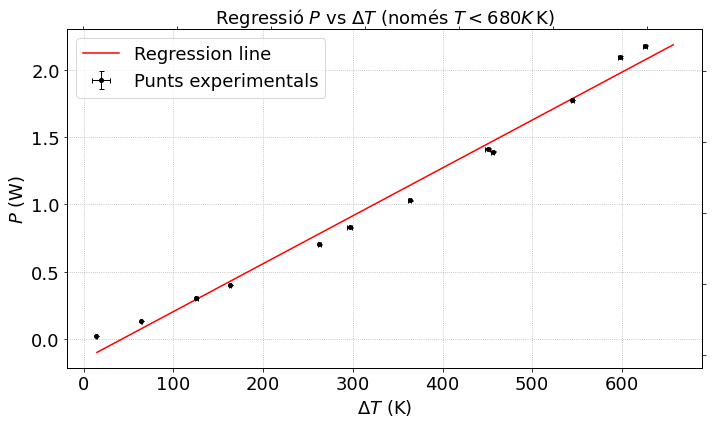

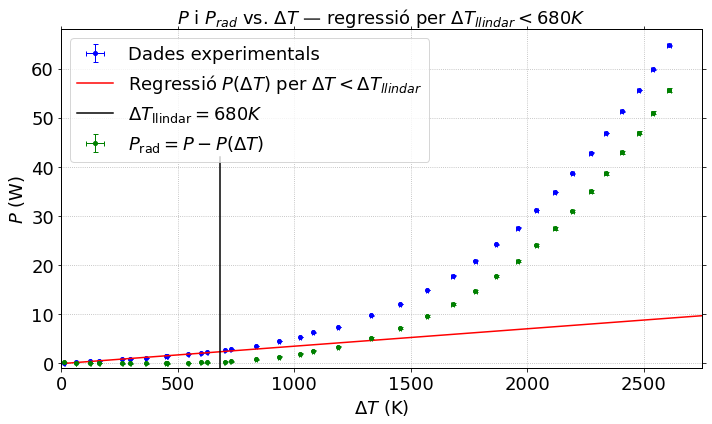

In [23]:
# --- Threshold & helpers ---
T_CUTOFF = T_llindari.magnitude  # K

# — Helpers (si no els tens ja) —
def get_dT(TK, Ta):
    # T en K; Ta en °C → converteix Ta a K
    expr = TK.var - (Ta.var)-273.15
    return formulador(expr, [TK, Ta],
                      "DeltaT de " + TK.name,
                      "dT_" + TK.var_name,
                      "K")

def pconv_from_dT(dT_meas, a_fit, b_fit):
    expr = a_fit.var + b_fit.var * dT_meas.var
    return formulador(expr, [dT_meas, a_fit, b_fit],
                      "P_conv(ΔT)", "Pconv_dT_" + dT_meas.var_name, "W")

# --- Build (ΔT, P) pairs and subset \Delta T <680 K ---
pairs_all = []
pairs_Tlt = []  # \Delta T < 680
T_list = Temperatures  # already built earlier alongside Potencies

dT_list = [ get_dT(T_i, T_ambient) for T_i in Temperatures ]

for P_i, dT_i, T_i in zip(Potencies, dT_list, T_list):
    pairs_all.append((dT_i, P_i))
    if T_i.magnitude < T_CUTOFF:
        pairs_Tlt.append((dT_i, P_i))

print(pairs_Tlt)
# --- Regression ONLY for \Delta T < 680 K:  P ≈ a + b ΔT  (this defines P_conv)
a_dT, b_dT, r_dT, _, _ = regresio(
    pairs_Tlt,
    r"$\Delta T$", "K",
    r"$P$", "W",
    r"Regressió $P$ vs $\Delta T$ (només $T<680 K\,\mathrm{K}$)",
    "display", fouraxis=True, grid=True
)
print("Convection fit (T<680 K):  P_conv(ΔT) = a + b ΔT")
print("  a =", a_dT)
print("  b =", b_dT)
print("  r =", r_dT)

# --- Build NEW P_conv from this fit for all points (as Measures) ---
Pconv_dT_list = [pconv_from_dT(dT_i, a_dT, b_dT) for dT_i in dT_list]

# --- Plot: data P vs ΔT, plus the new convection regression line (range limited to \Delta T<680 pts) ---
# Build a smooth line from min/max ΔT in the \Delta T<680 subset
if pairs_Tlt:
    import numpy as np
    dT_min = min(x.magnitude for x, _ in pairs_Tlt)
    dT_max = max(x.magnitude for x, _ in pairs_Tlt)
    x_line = np.linspace(dT_min, dT_max, 300)
    y_line = a_dT.magnitude + b_dT.magnitude * x_line
    reg_line_Tlt = list(zip(x_line, y_line))
else:
    reg_line_Tlt = []

to_plot = [pairs_all]
labels  = [r"Dades experimentals"]
styles  = ["o"]
colors  = ["blue"]

# y-range for the vertical line from existing data
yvals_all = [P.magnitude if isinstance(P, Measure) else P for _, P in pairs_all]
vline_dTthr = [(Delta_llindari, y) for y in np.linspace(-2, 42, 300)]

# --- Regression line extended over the WHOLE ΔT domain (not only T<561) ---
import numpy as np
dT_min_all = min(x.magnitude for x, _ in pairs_all)
dT_max_all = max(x.magnitude for x, _ in pairs_all)
x_line_full = np.linspace(dT_min_all, 3000, 400)
y_line_full = a_dT.magnitude + b_dT.magnitude * x_line_full
reg_line_full = list(zip(x_line_full, y_line_full))

# Append both series to the plot lists
to_plot.append(reg_line_full);  labels.append(r"Regressió $P(\Delta T)$ per $\Delta T < \Delta T_{llindar}$"); styles.append("-");  colors.append("red")
to_plot.append(vline_dTthr);    labels.append(r"$\Delta T_{\mathrm{llindar}}=680 K$");                   styles.append("--"); colors.append("black")

# --- Predicted radiation: P_rad(pred) = P - P_conv(ΔT) (pointwise) ---
Pconv_pred_list = [pconv_from_dT(dT_i, a_dT, b_dT) for dT_i in dT_list]
Prad_pred_pts   = [
    (dT_i, formulador(P_i.var - Pc_i.var, [P_i, Pc_i], "P_rad(pred)", "Prad_pred_" + P_i.var_name, "W"))
    for P_i, Pc_i, dT_i in zip(Potencies, Pconv_pred_list, dT_list)
]

# Add to the existing plot
to_plot.append(Prad_pred_pts)
labels.append(r"$P_{\mathrm{rad}} = P - P(\Delta T)$")
styles.append("o")          # points
colors.append("green")
graph_display(
    to_plot,
    r"$\Delta T$", "K",
    r"$P$", "W",
    r"$P$ i $P_{rad}$ vs. $\Delta T$ — regressió per $\Delta T_{llindar} < 680 K$", "P_vs_dT_conv_compare",
    labels=labels,
    llista_teos=styles,
    colors=colors,
    grid=True,
    fouraxis=True,
    xmin=0,ymin=-1,ymax=68,xmax=2750
)


<>:38: DeprecationWarning: invalid escape sequence \l
<>:38: DeprecationWarning: invalid escape sequence \l
<>:38: DeprecationWarning: invalid escape sequence \l
<ipython-input-25-19bc3b29a260>:38: DeprecationWarning: invalid escape sequence \l
  "$\ln P_{\mathrm{rad}}$ vs $\ln \Delta T$ per $\Delta T_{\mathrm{llindar}} < \Delta T$ ", r"fk",
/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:165: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)
See http://trac.sagemath.org/5930 for details.
/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:166: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)
See h

ln(P_rad) vs ln(T) — predicted radiation:
  intercept a = 'A: (-26.55651143510107 +/- 0.47743034660929884) '
  slope b     = 'B: (3.9018472486848226 +/- 0.06475308106893557)  units '  (Stefan–Boltzmann expects ~4)
  Pearson r   = 'Coe: (0.9942496393239019 +/- 0.100000000000000)  '


(<Figure size 720x432 with 3 Axes>,
 <AxesSubplot:title={'center':'$\\ln P_{\\mathrm{rad}}$ vs $\\ln \\Delta T$ per $\\Delta T_{\\mathrm{llindar}} < \\Delta T$ '}, xlabel='$\\ln \\Delta T$ (sense unitats)', ylabel='$\\ln P_{\\mathrm{rad}}$ (sense unitats)'>)

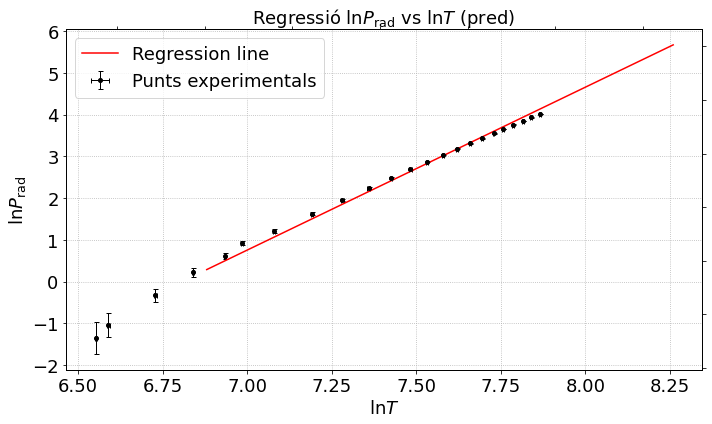

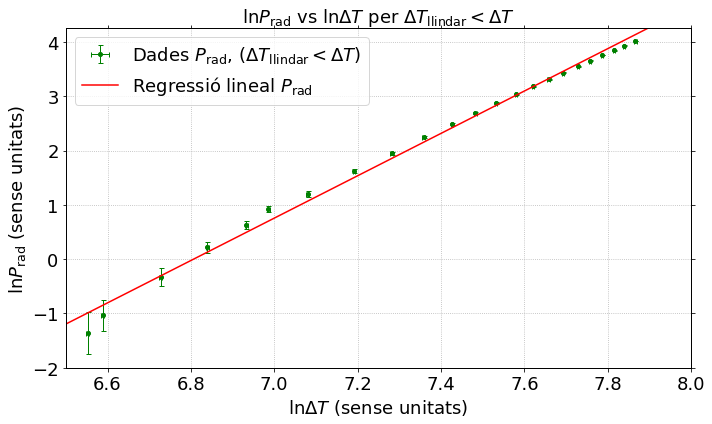

In [25]:
ln_pairs_pred = []
T_vals_pred   = []
# — Helpers (si no els tens ja) —
def s_log(meas):
    expr = log(meas.var)
    return formulador(expr, [meas],
                      "log de " + meas.name,
                      "ln_" + meas.var_name,
                      "logunit")
for ( _dT_i, Prad_i ), T_i in zip(Prad_pred_pts, Temperatures):
    if Prad_i.magnitude > 0 and T_i.magnitude > T_llindari.magnitude:
        ln_pairs_pred.append((s_log(_dT_i), s_log(Prad_i)))
        T_vals_pred.append(T_i.magnitude)

# Regression
a_pred, b_pred, r_pred, _, _ = regresio(
    ln_pairs_pred,
    r"$\ln T$", "", r"$\ln P_{\mathrm{rad}}$", "",
    r"Regressió $\ln P_{\mathrm{rad}}$ vs $\ln T$ (pred)",
    "display", fouraxis=True, grid=True
)
print("ln(P_rad) vs ln(T) — predicted radiation:")
print("  intercept a =", a_pred)
print("  slope b     =", b_pred, " (Stefan–Boltzmann expects ~4)")
print("  Pearson r   =", r_pred)

# Optional: draw the regression line in log–log space
import numpy as np
Tmin, Tmax = min(T_vals_pred), max(T_vals_pred)
x_ln = np.linspace(6.5, 8, 200)
y_ln = a_pred.magnitude + b_pred.magnitude * x_ln
reg_line_pred = list(zip(x_ln, y_ln))

graph_display(
    [ln_pairs_pred, reg_line_pred],
    r"$\ln \Delta T$", "sense unitats",
    r"$\ln P_{\mathrm{rad}}$", "sense unitats",
    "$\ln P_{\mathrm{rad}}$ vs $\ln \Delta T$ per $\Delta T_{\mathrm{llindar}} < \Delta T$ ", r"fk",
    labels=[r"Dades $P_{\mathrm{rad}} $, ($\Delta T_{\mathrm{llindar}} < \Delta T$)", r"Regressió lineal $P_{\mathrm{rad}}$"],
    llista_teos=["o", "-"],
    colors=["green", "red"],
    grid=True,
    fouraxis=True,xmin=6.5,xmax=8,ymax=4.25,ymin=-2
)

<>:16: DeprecationWarning: invalid escape sequence \D
<>:16: DeprecationWarning: invalid escape sequence \D
<>:16: DeprecationWarning: invalid escape sequence \D
<ipython-input-26-4ecfabee680c>:16: DeprecationWarning: invalid escape sequence \D
  "ln P vs. ln $\Delta T$", "lnPvslnT",
/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:165: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)
See http://trac.sagemath.org/5930 for details.
/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:166: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)
See http://trac.sagemath.org/5930 for details.


13.9241398759165
63.9329805996473
163.122729011283
262.746896686871
363.270759975173
455.748765622149
544.619356484839
625.841866801365
700.799136859045
125.271694420631
296.259285006244
450.175194191152
597.889354538291
726.626816992341
835.048321829202
933.451563404020
1025.65870643225
1080.65919767481
1188.13363189209
1327.87482880593
1452.78366176691
1569.43128096974
1679.08255256125
1776.77317259650
1865.52571071495
1957.95763040527
2038.33656279308
2116.93664196680
2192.80807222212
2271.30312787124
2337.18692006686
2404.70800973084
2477.88440311525
2538.58024691358
2607.57547665400


(<Figure size 720x432 with 3 Axes>,
 <AxesSubplot:title={'center':'ln P vs. ln $\\Delta T$'}, xlabel='$\\ln \\Delta T$ (sense unitats)', ylabel='$\\ln P$ (sense unitats)'>)

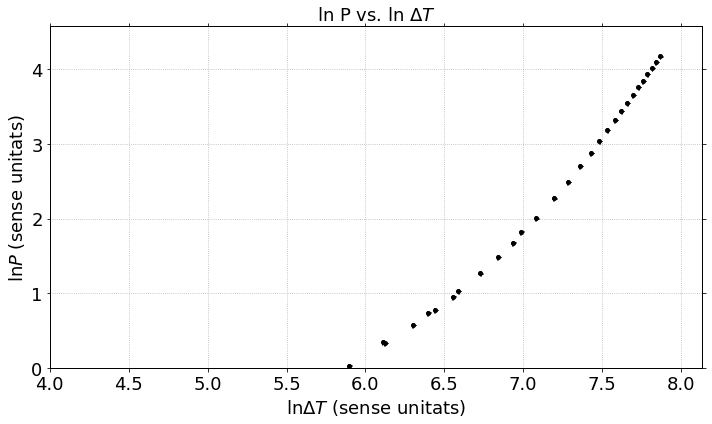

In [26]:

    
# — Construeix ΔT com a Measures —
dT_list = [ get_dT(T_i, T_ambient) for T_i in Temperatures ]

# — Construeix parelles (ln ΔT, ln P); filtra ΔT ≤ 0 —
ln_pairs = []
for P_i, dT_i in zip(Potencies, dT_list):
    print(dT_i.magnitude)
    if dT_i.magnitude > 0:
        ln_pairs.append( ( s_log(dT_i), s_log(P_i) ) )

# — Gràfic: ln P vs ln ΔT —
graph_display(
    [ln_pairs],
    r"$\ln \Delta T$", "sense unitats",
    r"$\ln P$", "sense unitats",
    "ln P vs. ln $\Delta T$", "lnPvslnT",
    labels=["Dades"],
    llista_teos=["o"],
    grid=True,
    fouraxis=True,ymin= 0,xmin=4
)


<>:42: DeprecationWarning: invalid escape sequence \D
<>:43: DeprecationWarning: invalid escape sequence \D
<>:43: DeprecationWarning: invalid escape sequence \D
<>:42: DeprecationWarning: invalid escape sequence \D
<>:43: DeprecationWarning: invalid escape sequence \D
<>:43: DeprecationWarning: invalid escape sequence \D
<>:42: DeprecationWarning: invalid escape sequence \D
<>:43: DeprecationWarning: invalid escape sequence \D
<>:43: DeprecationWarning: invalid escape sequence \D
<ipython-input-27-4871851c3698>:42: DeprecationWarning: invalid escape sequence \D
  "ln P vs. ln $\Delta T$", "lnPvslnT",
<ipython-input-27-4871851c3698>:43: DeprecationWarning: invalid escape sequence \D
  labels=["Dades experimentals", "Regressió ($ln(\Delta T) < 6.52$)", "Regressió ($ln(\Delta T) > 6.52$)", r"$ln(\Delta T) = 6.52$"][:len(dataset)],
<ipython-input-27-4871851c3698>:43: DeprecationWarning: invalid escape sequence \D
  labels=["Dades experimentals", "Regressió ($ln(\Delta T) < 6.52$)", "Regre

LOW  : slope = 'B: (1.2106399500385217 +/- 0.008974551470714718)  units '   intercept = 'A: (-7.057916046289561 +/- 0.049734372888037705) '   r = 'Coe: (0.9994507666394612 +/- 0.100000000000000)  '
HIGH : slope = 'B: (2.4979753326190424 +/- 0.04375956194217903)  units '   intercept = 'A: (-15.581303255085333 +/- 0.32264322377624044) '   r = 'Coe: (0.9935967699289188 +/- 0.100000000000000)  '


(<Figure size 720x432 with 3 Axes>,
 <AxesSubplot:title={'center':'ln P vs. ln $\\Delta T$'}, xlabel='$\\ln \\Delta T$ (sense unitats)', ylabel='$\\ln P$ (sense unitats)'>)

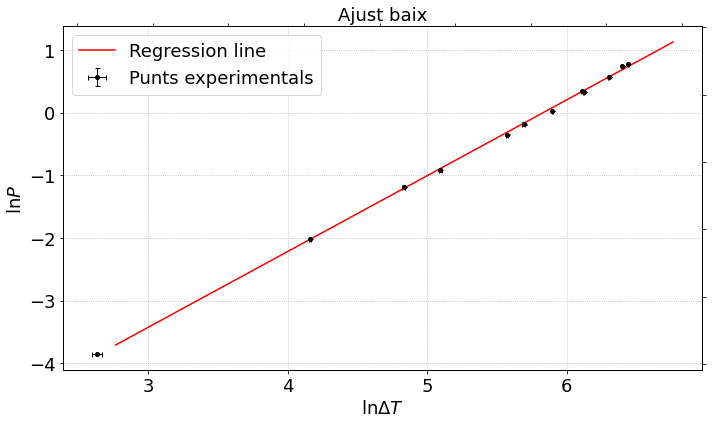

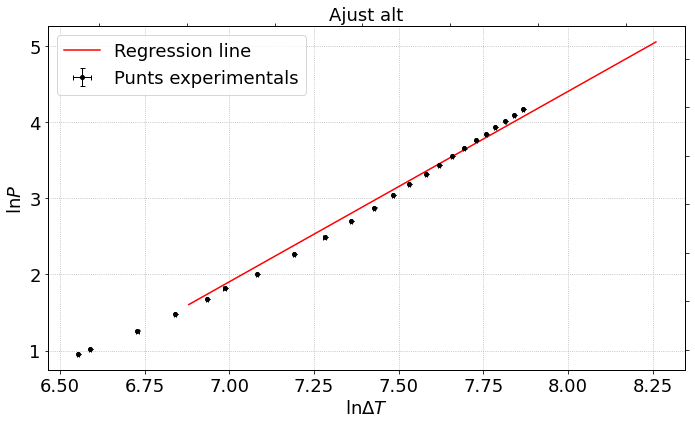

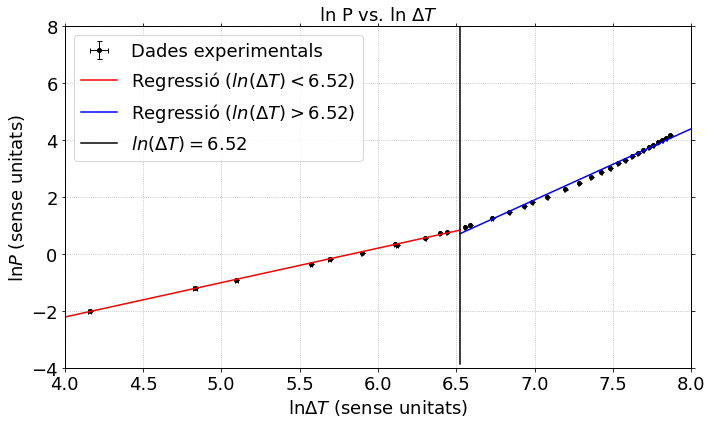

In [27]:

# --- Split by threshold on x = ln(ΔT) ---
X_THRESH =ln(Delta_llindari)
ln_low  = [(x, y) for (x, y) in ln_pairs if x.magnitude <  X_THRESH]
ln_high = [(x, y) for (x, y) in ln_pairs if x.magnitude >= X_THRESH]

# --- Regressions on each subset (a,b are Measures) ---
a_low,  b_low,  r_low,_,_  = regresio(ln_low,  r"$\ln \Delta T$", "", r"$\ln P$", "", r"Ajust baix",  "display", grid=True, fouraxis=True)
a_high, b_high, r_high,_,_ = regresio(ln_high, r"$\ln \Delta T$", "", r"$\ln P$", "", r"Ajust alt",   "display", grid=True, fouraxis=True)

print("LOW  : slope =", b_low,  "  intercept =", a_low,  "  r =", r_low)
print("HIGH : slope =", b_high, "  intercept =", a_high, "  r =", r_high)

# --- Build x-ranges and regression lines using np.linspace (numeric tuples are fine) ---
def build_line(a_meas, b_meas, x_min, x_max, n=200):
    xs = np.linspace(x_min, x_max, n)
    return [(float(x), float(a_meas.magnitude + b_meas.magnitude * x)) for x in xs]

# ranges for each subset
x_low_vals  = [xy[0].magnitude for xy in ln_low]  if ln_low  else []
x_high_vals = [xy[0].magnitude for xy in ln_high] if ln_high else []
y_all_vals  = [xy[1].magnitude for xy in ln_pairs]

# guard in case a subset is empty
low_line  = build_line(a_low,  b_low,  0,  X_THRESH)  if x_low_vals  else []
high_line = build_line(a_high, b_high, X_THRESH,  100) if x_high_vals else []

# --- Vertical line at x = 6.8 built from previous y-range using np.linspace ---
ymin, ymax = min(y_all_vals), max(y_all_vals)
vline_y = np.linspace(ymin, 10, 500)
vline   = [(X_THRESH, float(y)) for y in vline_y]

# --- Plot: whole dataset (points), both regression lines, and the vertical split line ---
dataset = [ln_pairs]  # all points
if low_line:  dataset.append(low_line)
if high_line: dataset.append(high_line)
dataset.append(vline)

graph_display(
    dataset,
    r"$\ln \Delta T$", "sense unitats",
    r"$\ln P$",        "sense unitats",
    "ln P vs. ln $\Delta T$", "lnPvslnT",
    labels=["Dades experimentals", "Regressió ($ln(\Delta T) < 6.52$)", "Regressió ($ln(\Delta T) > 6.52$)", r"$ln(\Delta T) = 6.52$"][:len(dataset)],
    llista_teos=["o", "--", "--", ":" ][:len(dataset)],
    colors=["black","red","blue","black"],
    grid=True,
    fouraxis=True,
    xmax=8,ymax=8,ymin=-4.00001,xmin=4
)

[53.7685279187817, 65.8666666666667, 89.8626506024096, 113.963729246488, 138.282462253194, 160.654741379310, 182.154314720812, 201.803664416586, 219.937327188940, 80.7057283142390, 122.071046228710, 159.306382978723, 195.041392649903, 226.185559566787, 252.414890016920, 276.220602218700, 298.527354260090, 311.833073101490, 337.833288227334, 371.639478584730, 401.857423454650, 430.076815492200, 456.603651115619, 480.236965914546, 501.707979936160, 524.069109947644, 543.514381270903, 562.529312424608, 580.884128831975, 599.873652694611, 615.812259702575, 632.146961714085, 649.849794801642, 664.533333333333, 681.224659312135]
Intercept a_low = 'A: (-0.8913285681996924 +/- 0.07185170920481551) W'
Slope b_low     = 'B: (0.014692954926946453 +/- 0.0005167941616334655)  units '
Pearson r       = 'Coe: (0.987779835255754 +/- 0.100000000000000)  '
Resistencia inicial per regresió: 'Resistència inicial regresió: (60.6636699446360 +/- 5.33544356215503) Ohm'


/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:165: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)
See http://trac.sagemath.org/5930 for details.
/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:166: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)
See http://trac.sagemath.org/5930 for details.


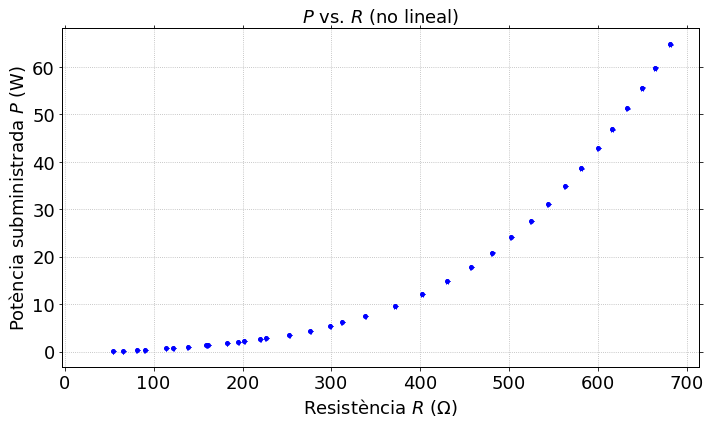

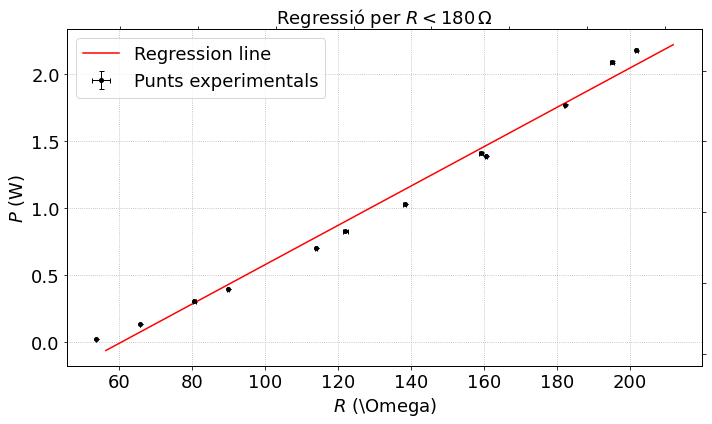

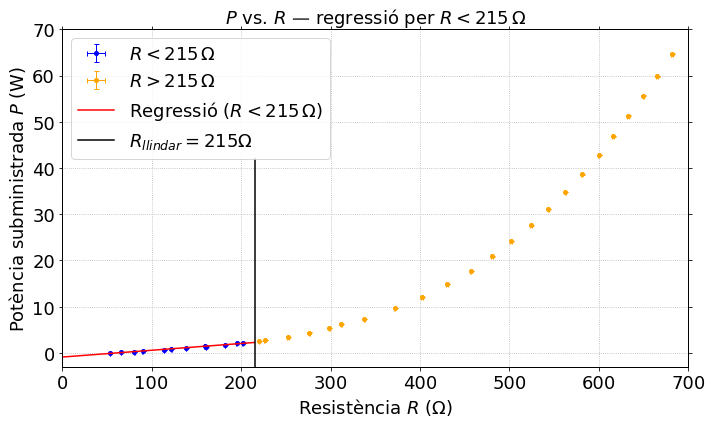

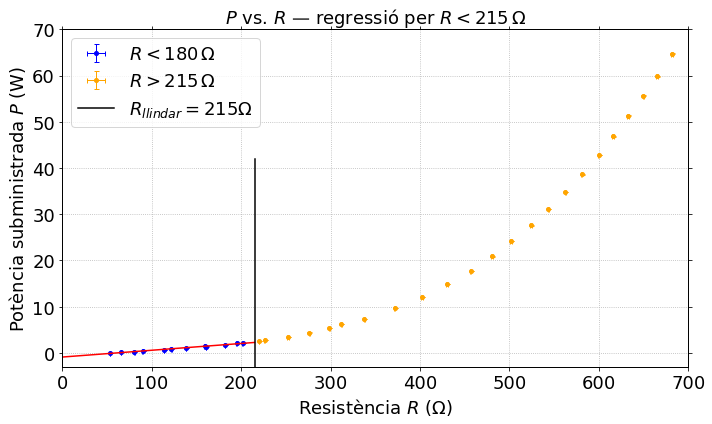

In [28]:
# Use corrected resistances if you stored them in `Resistencies`
rp_data = [(r, p) for p, r in zip(Potencies, Resistencies)]
print([r.magnitude for p, r in zip(Potencies, Resistencies)])
graph_display(
    [rp_data],
    r"Resistència $R$", r"$\Omega$",
    r"Potència subministrada $P$", "W",
    r"$P$ vs. $R$ (no lineal)", "P vs. R (no lineal)",
    labels=["Dades"],
    llista_teos=["o"],
    colors=["blue"],
    grid=True,
    fouraxis=True,
    xmin = -3
)


R_THRESHOLD = R_llindari.magnitude
# Split by resistance
low  = [(r, p) for (r, p) in rp_data if r.magnitude < R_THRESHOLD]
high = [(r, p) for (r, p) in rp_data if r.magnitude >= R_THRESHOLD]

# Linear regression ONLY on the low-R subset
a_low, b_low, r_low,_,_ = regresio(
    low,
    r"$R$", r"\Omega",
    r"$P$", "W",
    r"Regressió per $R<180\,\Omega$",
    "display", fouraxis=True, grid=True
)

# Build regression line over the low-R range
Rmin = 0
Rmax = 800
x_lin = np.linspace(Rmin, R_THRESHOLD, 1000)
y_lin = a_low.magnitude + b_low.magnitude * x_lin
reg_low = list(zip(x_lin, y_lin))


# --- Vertical line at R = R_THRESHOLD built from previous y-range using np.linspace ---
ymin, ymax = -100, 42
vline_y = np.linspace(ymin, ymax, 500)
vline   = [(R_THRESHOLD, float(y)) for y in vline_y]


# Plot: data for both regions + regression (only low)
graph_display(
    [low, high, reg_low,vline],
    r"Resistència $R$", r"$\Omega$",
    r"Potència subministrada $P$", "W",
     r"$P$ vs. $R$ — regressió per $R<215\,\Omega$",  "RvsP_reg",
    labels=[r"$R<215\,\Omega$", r"$R > 215\,\Omega$", r"Regressió ($R<215\,\Omega$)", r"$R_{llindar} = 215 \Omega$"],
    llista_teos=["o", "o", "-","--"],
    colors=["blue", "orange", "red","black"],
    grid=True,
    fouraxis=True,
    xmin=0,ymin = -3,ymax=70,xmax=700
)

graph_display(
    [low, high, reg_low,vline],
    r"Resistència $R$", r"$\Omega$",
    r"Potència subministrada $P$", "W",
     r"$P$ vs. $R$ — regressió per $R<215\,\Omega$",  "RvsP_reg",
    labels=[r"$R<180\,\Omega$", r"$R > 215\,\Omega$", r"", r"$R_{llindar} = 215 \Omega$"],
    llista_teos=["o", "o", "-","--"],
    colors=["blue", "orange", "red","black"],
    grid=True,
    fouraxis=True,
    xmin=0,ymin = -3,ymax=70,xmax=700
)


print("Intercept a_low =", a_low)
print("Slope b_low     =", b_low)
print("Pearson r       =", r_low)
print("Resistencia inicial per regresió:", formulador(-a_low.var/b_low.var,[a_low,b_low], "Resistència inicial regresió", "R_0_reg", "Ohm"))

<>:29: DeprecationWarning: invalid escape sequence \O
<>:29: DeprecationWarning: invalid escape sequence \O
<>:29: DeprecationWarning: invalid escape sequence \O
<ipython-input-29-b49def01d5e2>:29: DeprecationWarning: invalid escape sequence \O
  r"Regressió $P(\Delta T)$ ($R<%d\,\Omega$)" % R_THRESHOLD, "$R_{llindar} = 180\Omega $",
/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:165: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)
See http://trac.sagemath.org/5930 for details.
/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:166: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)
See http://tr

(<Figure size 720x432 with 3 Axes>,
 <AxesSubplot:title={'center':'$P$ vs. $R$ — regressió ($R<215\\,\\Omega$) i $P_{\\mathrm{rad}}=P-P(\\Delta T)$'}, xlabel='Resistència $R$ ($\\Omega$)', ylabel='Potència $P$ i $P_{\\mathrm{rad}}$ (W)'>)

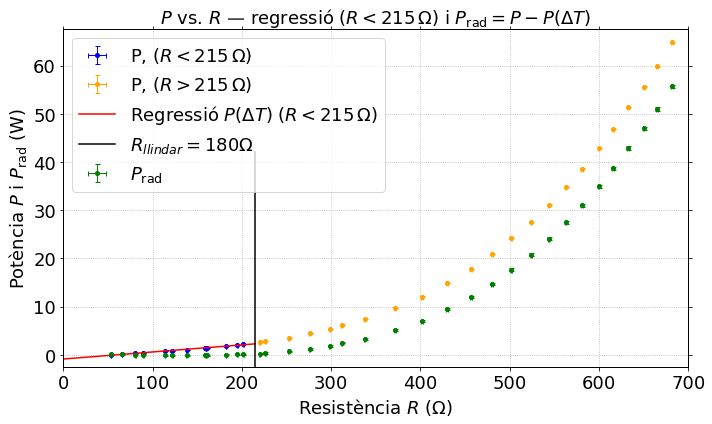

In [29]:
# --- Helpers to keep everything as Measures (uncertainty propagates) ---
def conv_from_reg(R_meas, a_fit, b_fit):
    expr = a_fit.var + b_fit.var * R_meas.var
    return formulador(expr, [R_meas, a_fit, b_fit],
                      "P_conv (model lineal) per " + R_meas.name,
                      "Pconv_" + R_meas.var_name,
                      "W")

def prad_from_balance(P_meas, Pconv_meas):
    expr = P_meas.var - Pconv_meas.var
    return formulador(expr, [P_meas, Pconv_meas],
                      "P_radiada per " + P_meas.name,
                      "Prad_" + P_meas.var_name,
                      "W")

Prad_pts = []
for (R_i, P_i) in rp_data:
    Pconv_i = conv_from_reg(R_i, a_low, b_low)
    Prad_i  = prad_from_balance(P_i, Pconv_i)
    Prad_pts.append((R_i, Prad_i))  # points, not a line

# Re-plot including P_rad as POINTS (no line)
graph_display(
    [low, high, reg_low, vline, Prad_pts],
    r"Resistència $R$", r"$\Omega$",
    r"Potència $P$ i $P_{\mathrm{rad}}$", "W",
    r"$P$ vs. $R$ — regressió ($R<%d\,\Omega$) i $P_{\mathrm{rad}}=P-P(\Delta T)$" % R_THRESHOLD,"pvsr_finale" ,
    labels=[r"P, ($R<%d\,\Omega$)" % R_THRESHOLD, r"P, ($R> %d\,\Omega$)" % R_THRESHOLD,
            r"Regressió $P(\Delta T)$ ($R<%d\,\Omega$)" % R_THRESHOLD, "$R_{llindar} = 180\Omega $",
            r"$P_{\mathrm{rad}}$"],
    llista_teos=["o", "o", "-", "--", "o"],
    colors=["blue", "orange", "red", "black", "green"],
    grid=True,
    fouraxis=True,
    xmin=0, ymin=-2.500001, ymax=67.5, xmax=700
)


/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:165: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)
See http://trac.sagemath.org/5930 for details.
/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:166: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)
See http://trac.sagemath.org/5930 for details.
/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:165: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)


High-T regression:
  Intercept a = 'A: (-33.67053300934789 +/- 0.8283356817632394) '
  Slope b     = 'B: (4.748478958146396 +/- 0.10964416624107809)  units '  (Stefan–Boltzmann expects 4)
  Deviation   = b - 4 = 0.7485  (18.71%)
  Pearson r   = 'Coe: (0.9889274979125166 +/- 0.100000000000000)  '


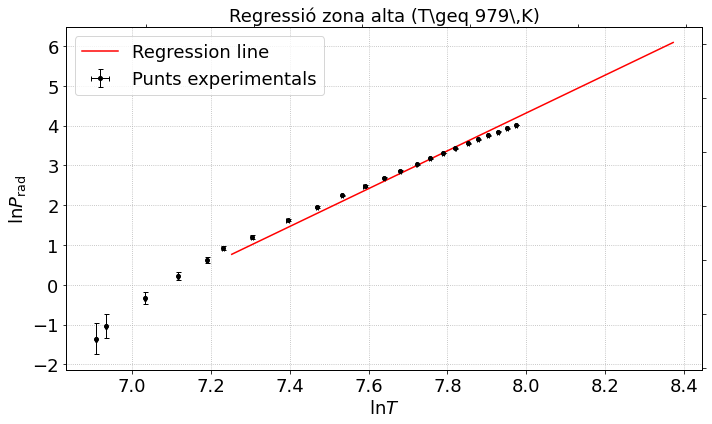

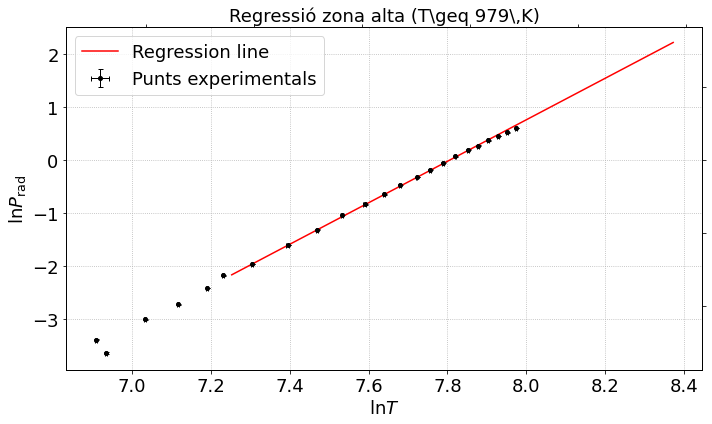

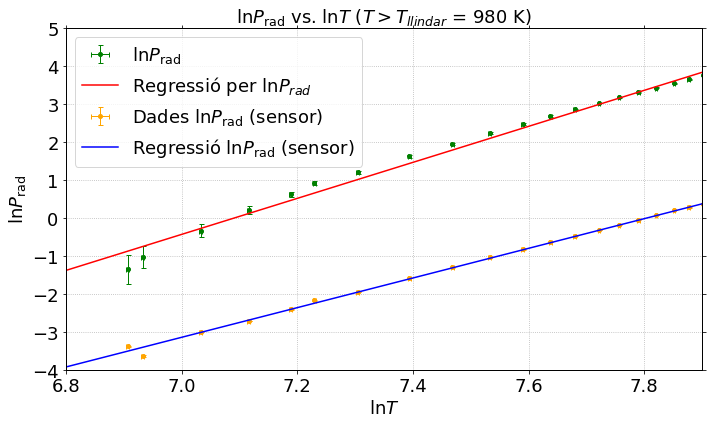

In [30]:
T_THRESHOLD_MEASURE = T_llindari
T_THRESHOLD = T_llindari.magnitude
# --- Build ln(T) vs ln(P_rad) for ALL points using the low-R convection model ---
ln_pairs_lowT  = []  # T < T_THRESHOLD
ln_pairs_highT = []  # T >= T_THRESHOLD
T_vals_high    = []  # to build regression line domain in ln-space later

for P_i, R_i, dT_i, T_i in zip(Potencies, Resistencies, dT_list,Temperatures):
    Pconv_i = conv_from_reg(dT_i, a_dT, b_dT)    # convection estimate from low-R fit
    Prad_i  = prad_from_balance(P_i, Pconv_i)     # radiation-only power
    pair = (s_log(T_i), s_log(Prad_i))
    if T_i.magnitude < T_llindari.magnitude:
        ln_pairs_lowT.append(pair)
    else:
        ln_pairs_highT.append(pair)
        T_vals_high.append(T_i.magnitude)

# --- Regression ONLY on the high-T subset ---
if len(ln_pairs_highT) >= 2:
    a_high, b_high, r_high, _, _ = regresio(
        ln_pairs_highT,
        r"$\ln T$", "", r"$\ln P_{\mathrm{rad}}$", "",
        r"Regressió zona alta (T\geq %.0f\,K)" % T_THRESHOLD,
        "display", fouraxis=True, grid=True
    )

    # Build regression line starting at ln(T_THRESHOLD) to ln(max T in high set)
    Tmin_h = max(T_THRESHOLD, min(T_vals_high))
    Tmax_h = max(T_vals_high)
    x_ln = np.linspace(0, 10, 200)
    y_ln = a_high.magnitude + b_high.magnitude * x_ln
    reg_high_line = list(zip(x_ln, y_ln))
else:
    a_high = b_high = r_high = None
    reg_high_line = []

# --- Plot: points for both zones + (optional) regression line for high-T ---
to_plot = [ln_pairs_highT]
labels  = [r"$\ln P_{\mathrm{rad}}$ "]
styles  = ["o"]
colors  = ["green"]

if reg_high_line:
    to_plot.append(reg_high_line)
    labels.append(r"Regressió per $\ln P_{rad}$")
    styles.append("-")
    colors.append("red")
    
ln_Tthr = formulador(log(T_THRESHOLD_MEASURE.var), [T_THRESHOLD_MEASURE], "log T llindar", "ln_Tthr", "logK")
y_all   = [pt[1].magnitude for pt in (ln_pairs_lowT + ln_pairs_highT)]
vline_lnTthr = [(ln_Tthr.magnitude, y) for y in np.linspace(-50, 10, 400)]

# Add experimental P_rad (from Radiacions) vs Temperatures as ln-points
ln_pairs_sensor_high = []
for Prad_s, T_i in zip(Radiacions, Temperatures):
    if T_i.magnitude >= T_llindari.magnitude:
        ln_pairs_sensor_high.append((s_log(T_i), s_log(Prad_s)))



to_plot.append(ln_pairs_sensor_high)
labels.append(r"Dades $\ln P_{\mathrm{rad}}$ (sensor)")
styles.append("o")
colors.append("orange")

a_sensor, b_sensor, r_sensor, _, _ = regresio(
        ln_pairs_sensor_high,
        r"$\ln T$", "", r"$\ln P_{\mathrm{rad}}$", "",
        r"Regressió zona alta (T\geq %.0f\,K)" % T_THRESHOLD,
        "display", fouraxis=True, grid=True
    )

y_ln = a_sensor.magnitude + b_sensor.magnitude * x_ln
reg_sensor = list(zip(x_ln, y_ln))

to_plot.append(reg_sensor)
labels.append(r"Regressió $\ln P_{\mathrm{rad}}$ (sensor)")
styles.append("--")
colors.append("blue")
# add to your existing plot call:
#to_plot.append(vline_lnTthr); labels.append(r"$\ln T_{\mathrm{thr}}$"); styles.append("--"); colors.append("black")
graph_display(
    to_plot,
    r"$\ln T$", "",
    r"$\ln P_{\mathrm{rad}}$", "",
    r"$\ln P_{\mathrm{rad}}$ vs. $\ln T$ ($T >  T_{llindar}$ = 980 K)", "lastlastgraph" ,
    labels=labels,
    llista_teos=styles,
    colors=colors,
    grid=True,
    fouraxis=True,ymin=-4,ymax=5,xmax=7.9,xmin=6.8
)

# --- Print comparison vs Stefan–Boltzmann (slope ≈ 4) ---
if b_high is not None:
    slope = b_high.magnitude
    diff  = slope - 4.0
    rel   = 100.0 * abs(diff) / 4.0
    print("High-T regression:")
    print("  Intercept a =", a_high)
    print("  Slope b     =", b_high, " (Stefan–Boltzmann expects 4)")
    print("  Deviation   = b - 4 = %.4f  (%.2f%%)" % (diff, rel))
    print("  Pearson r   =", r_high)
else:
    print("Not enough high-T points (>=2) to fit the regression.")

In [35]:

print("  Intercept a =", a_sensor)
print("  Slope b     =", b_sensor, " (Stefan–Boltzmann expects 4)")
r_sensor

  Intercept a = 'A: (-30.51893326116627 +/- 0.29980965246587593) '
  Slope b     = 'B: (3.9106696798654745 +/- 0.03968485252944127)  units '  (Stefan–Boltzmann expects 4)


'Coe: (0.9978421144963006 +/- 0.100000000000000)  '

/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:165: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)
See http://trac.sagemath.org/5930 for details.
/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:166: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)
See http://trac.sagemath.org/5930 for details.


High-T model in original space:  P_rad(T) = exp(a) * T^b
  a = 'A: (-33.67053300934789 +/- 0.8283356817632394) '    b = 'B: (4.748478958146396 +/- 0.10964416624107809)  units '
  => exp(a) ≈ 2.3827216519418567e-15


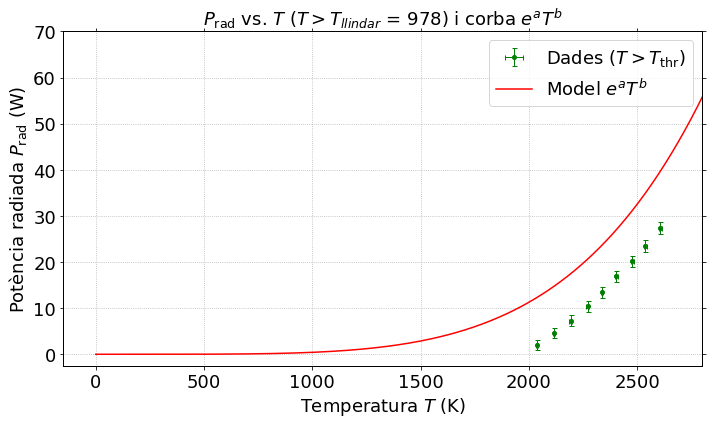

In [32]:
import numpy as np

# --- Rebuild zone-2 (high-T) points in ORIGINAL space: (T, P_rad) ---
high_TR_pts = []  # (T, P_rad) with T >= T_THRESHOLD
T_high_vals = []

for P_i, R_i, T_i in zip(Potencies, Resistencies, dT_list):
    if T_i.magnitude >= T_THRESHOLD:
        Pconv_i = conv_from_reg(T_i, a_low, b_low)
        Prad_i  = prad_from_balance(P_i, Pconv_i)
        if Prad_i.magnitude > 0:       # model is meaningful for P_rad>0
            high_TR_pts.append((T_i, Prad_i))
            T_high_vals.append(T_i.magnitude)

# --- Build model curve: P_rad_model(T) = exp(a_high) * T^(b_high) ---
if a_high is not None and b_high is not None and len(T_high_vals) >= 2:
    Tmin_h = 0
    Tmax_h = 3000
    T_grid = np.linspace(Tmin_h, Tmax_h, 300)
    P_model = np.exp(a_high.magnitude) * (T_grid ** b_high.magnitude)
    model_curve = list(zip(T_grid, P_model))
else:
    model_curve = []

# --- Plot in ORIGINAL space: T (K) vs P_rad (W) ---
graph_display(
    [high_TR_pts, model_curve] if model_curve else [high_TR_pts],
    r"Temperatura $T$", "K",
    r"Potència radiada $P_{\mathrm{rad}}$", "W",
    r"$P_{\mathrm{rad}}$ vs. $T$ ($T >  T_{llindar}$ = %d) i corba $e^{a}T^{b}$" % T_THRESHOLD, "fuckme", 
    labels=[r"Dades ($T > T_{\mathrm{thr}}$)", r"Model $e^{a}T^{b}$"] if model_curve else [r"Dades experimentals"],
    llista_teos=["o", "-"] if model_curve else ["o"],
    colors=["green", "red"] if model_curve else ["green"],
    grid=True,
    fouraxis=True,xmax=2800,ymax=70,ymin=-2.5
)

# Print fitted model parameters again for clarity
if a_high is not None and b_high is not None:
    print("High-T model in original space:  P_rad(T) = exp(a) * T^b")
    print("  a =", a_high, "   b =", b_high)
    print("  => exp(a) ≈", np.exp(a_high.magnitude))


FileNotFoundError: [Errno 2] No such file or directory: '$\\Delta T$ i $T$ vs. índex.png'

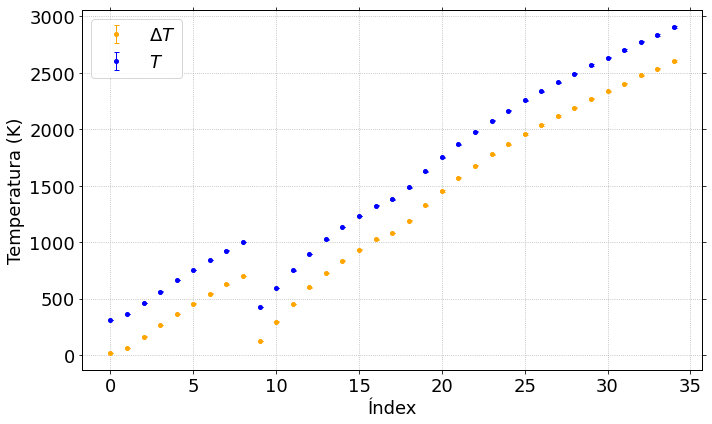

In [33]:
# Build two series: (index, value)
dT_series = [(i, dT_i) for i, dT_i in enumerate(dT_list)]
T_series  = [(i, T_i)  for i, T_i  in enumerate(Temperatures)]

graph_display(
    [dT_series, T_series],
    r"Índex", "",
    r"Temperatura", "K",
    "",
    r"$\Delta T$ i $T$ vs. índex",
    labels=[r"$\Delta T$", r"$T$"],
    llista_teos=["o", "o"],
    colors=["orange", "blue"],
    grid=True,
    fouraxis=True
)
